# Projet de Scoring de Crédit : Prédiction du Défaut de Paiement

**Présenté par : [Sahli Wissem]**

## 1. Introduction
L'objectif de ce projet est de prédire le risque de défaut de paiement (`Status`) à partir d'un jeu de données bancaires complexe contenant 34 variables.

### Problématique :
Comment identifier les facteurs discriminants (financiers et démographiques) qui permettent d'anticiper l'incapacité d'un emprunteur à rembourser son prêt ?

![image.png](attachment:image.png)

## Méthodologie de travail

Notre approche suit les étapes classiques d'un projet de machine learning, en se concentrant sur la robustesse et l'interprétabilité des résultats :

1.  **Chargement des données :** Récupération du jeu de données via Kaggle API.
2.  **Exploration et Nettoyage des Données :** Analyse des statistiques descriptives, gestion des valeurs manquantes et des doublons.
3.  **Feature Engineering :** Création de nouvelles variables pertinentes (ex: `mensualite`, `term_bucket`).
4.  **Préparation des Données pour le Modèle :** Encodage des variables catégorielles, standardisation des variables numériques.
5.  **Gestion du Déséquilibre des Classes (SMOTE) :** Suréchantillonnage de la classe minoritaire pour améliorer la performance du modèle sur la prédiction des défauts.
6.  **Modélisation :** Entraînement et fine-tuning de plusieurs modèles (Régression Logistique, Random Forest, XGBoost, Ensemble).
7.  **Évaluation :** Comparaison des performances sur un jeu de test indépendant et analyse de l'importance des variables.

In [1]:
import time

start_time  = time.time()

## 2. Chargement des données
Nous utilisons la bibliothèque `kagglehub` pour récupérer la version la plus récente du dataset "Loan Default Dataset".

Pour cette étape, nous allons charger le jeu de données `loan-default-dataset` depuis Kaggle et l'intégrer dans un DataFrame Pandas pour commencer notre analyse. Cette approche garantit l'accès à la dernière version du dataset et facilite sa manipulation.

Cette section est dédiée à la compréhension de la structure de nos données. Nous examinerons les types de variables, les statistiques descriptives, et les distributions pour identifier d'éventuels problèmes comme les valeurs manquantes ou les valeurs aberrantes. La visualisation est un outil clé ici pour révéler les tendances et les relations initiales entre les variables.

Installation des bibliothèques nécessaires pour l'analyse de données, la gestion des datasets et le machine learning

In [2]:
import sys
!{sys.executable} -m pip install xgboost dython missingno kagglehub pandas matplotlib seaborn scikit-learn imbalanced-learn scipy



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import kagglehub
from pathlib import Path
import shutil
import os


# création du dossier local ( qui contiendra la base )

data_folder = Path('data')
data_folder.mkdir(exist_ok=True)

# téléchargement de la base avec Kaggle API

try :
    path = Path(kagglehub.dataset_download("yasserh/loan-default-dataset"))
    print("Téléchargement de la dernière version réussi.")

    files = [ f for f in os.listdir(path) if f.endswith(".csv")]
    src_file = path / files[0]
    data = data_folder / "data.csv"

    shutil.copy(src_file , data )
    print(f"Fichier copié avec succès dans : {data}")

except Exception as e :
    print(f"Erreur : {e}")



/Users/wess/Desktop/CreditGuard-ML-Scoring/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Téléchargement de la dernière version réussi.
Fichier copié avec succès dans : data/data.csv


In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import pandas as pd

df = pd.read_csv(data)
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


## 3. Exploration et Nettoyage des Données

In [6]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='str')

In [7]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  str    
 3   Gender                     148670 non-null  str    
 4   approv_in_adv              147762 non-null  str    
 5   loan_type                  148670 non-null  str    
 6   loan_purpose               148536 non-null  str    
 7   Credit_Worthiness          148670 non-null  str    
 8   open_credit                148670 non-null  str    
 9   business_or_commercial     148670 non-null  str    
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            109028 non-nu

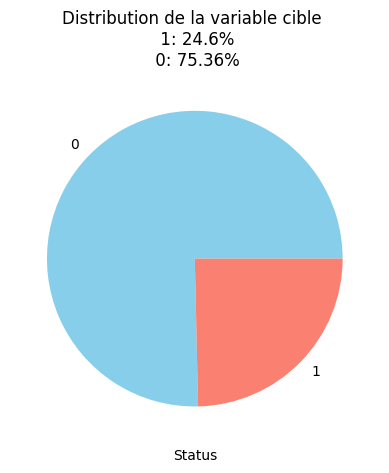

In [9]:
import matplotlib.pyplot as plt

df["Status"].value_counts().plot(kind='pie',colors=['skyblue','salmon'])
plt.title(f'Distribution de la variable cible \n 1: {(df["Status"]==1).mean()*100:.1f}%\n 0: {(df["Status"]==0).mean()*100:.2f}%')
plt.xlabel('Status')
plt.xticks(rotation=0)
plt.show()

## Les valeurs dupliquées

In [10]:
df = df.drop_duplicates()

## Création de la train_test Set

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop('Status',axis=1)
y = df['Status']

X_train,X_test , y_train , y_test = train_test_split(X ,y,
                              test_size=0.2,
                              random_state=42,
                              stratify=df['Status'])

X_train = X_train.reset_index(drop=True)
X_train_2 = X_train.copy()

y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Proportion dans le Train :\n", y_train.value_counts(normalize=True))
print("\nProportion dans le Test :\n", y_test.value_counts(normalize=True))


Proportion dans le Train :
 Status
0    0.753557
1    0.246443
Name: proportion, dtype: float64

Proportion dans le Test :
 Status
0    0.753548
1    0.246452
Name: proportion, dtype: float64


## Les valeurs manquantes

Les valeurs manquantes peuvent biaiser nos modèles et réduire leur performance. Dans cette phase, nous allons d'abord identifier l'étendue du problème, puis appliquer des stratégies d'imputation adaptées pour chaque type de variable, en utilisant des méthodes statistiques ou basées sur l'apprentissage automatique pour remplir les lacunes de manière cohérente.

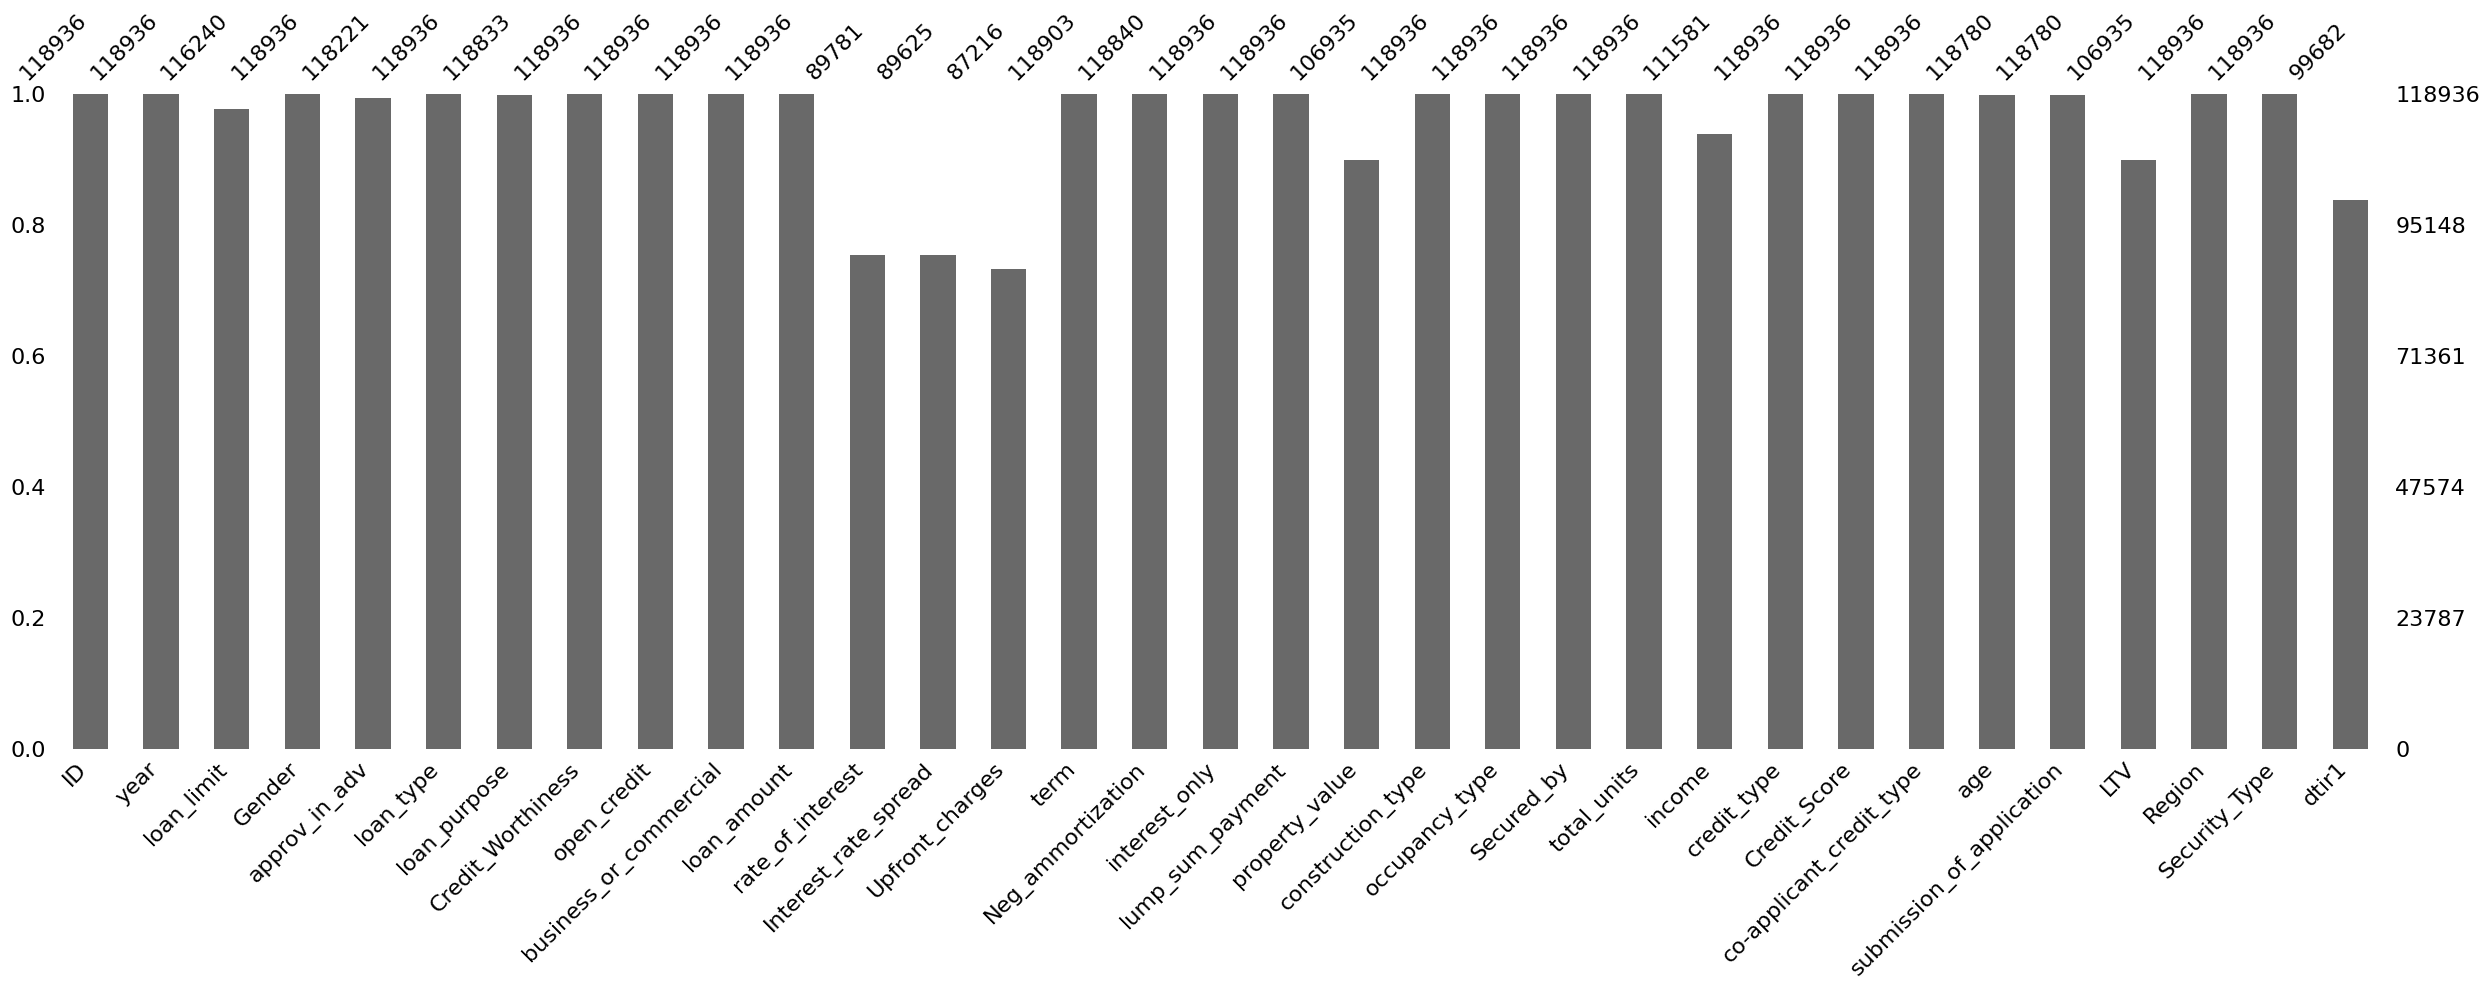

In [12]:
import missingno as msno
import matplotlib.pyplot as plt

msno.bar(X_train)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
print('Pourcentage des valeurs manquantes par colonnes : \n')

missing = (X_train.isnull().mean()*100).round(2).sort_values(ascending=False)
print (missing[ missing > 0])

Pourcentage des valeurs manquantes par colonnes : 

Upfront_charges              26.67
Interest_rate_spread         24.64
rate_of_interest             24.51
dtir1                        16.19
property_value               10.09
LTV                          10.09
income                        6.18
loan_limit                    2.27
approv_in_adv                 0.60
submission_of_application     0.13
age                           0.13
loan_purpose                  0.09
Neg_ammortization             0.08
term                          0.03
dtype: float64


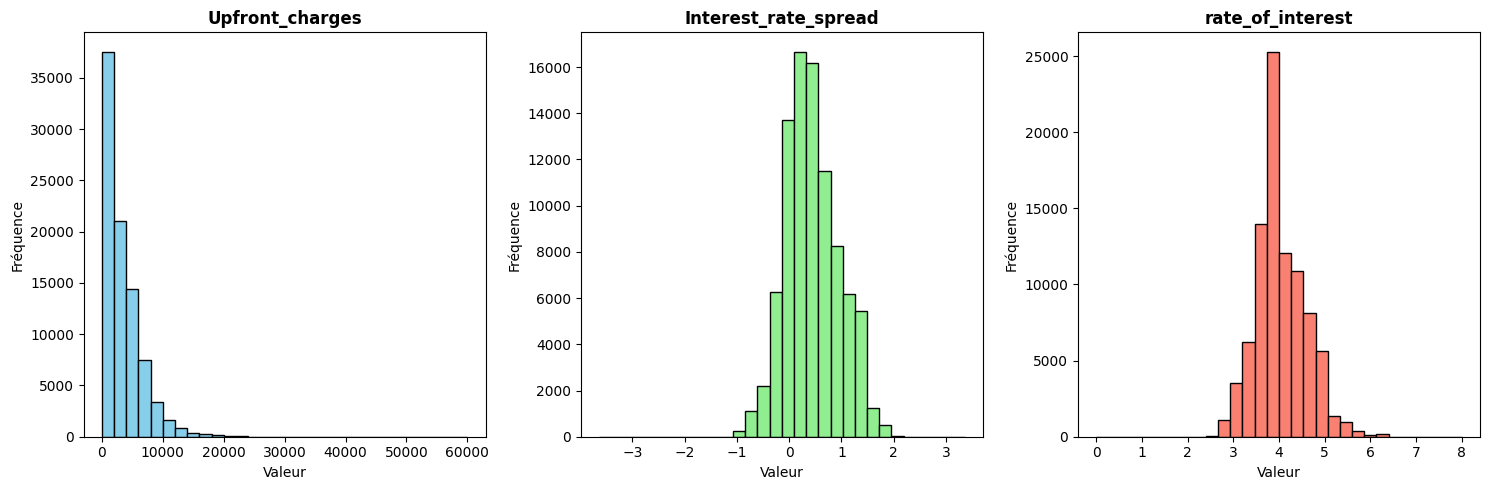

In [14]:
high_missing = ['Upfront_charges', 'Interest_rate_spread', 'rate_of_interest', 'dtir1', 'property_value', 'LTV']

import matplotlib.pyplot as plt

# Créer une figure avec 3 subplots (1 ligne, 3 colonnes)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Premier histogramme
axes[0].hist(X_train['Upfront_charges'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Upfront_charges', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valeur')
axes[0].set_ylabel('Fréquence')

# Deuxième histogramme
axes[1].hist(X_train['Interest_rate_spread'], bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Interest_rate_spread', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Valeur')
axes[1].set_ylabel('Fréquence')

# Troisième histogramme
axes[2].hist(X_train['rate_of_interest'], bins=30, color='salmon', edgecolor='black')
axes[2].set_title('rate_of_interest', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Valeur')
axes[2].set_ylabel('Fréquence')

# Ajuster l'espacement entre les subplots
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer


# 1. Sélection des colonnes

num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

limites_basses = [-np.inf if col == 'Interest_rate_spread' else 0 for col in num_cols]

# 2. Imputation Numérique (Iterative)
numeric_imputer = IterativeImputer(max_iter=10, min_value=limites_basses)


X_train_num = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)

# 3. Imputation Catégorielle (Most Frequent)
categorical_imputer = SimpleImputer(strategy="most_frequent")
X_train_cat = pd.DataFrame(
    categorical_imputer.fit_transform(X_train[cat_cols]),
    columns=cat_cols,
    index=X_train.index
)

# 4. Concatenation finale
X_train = pd.concat([X_train_num, X_train_cat], axis=1)

X_train['Upfront_charges'] = X_train['Upfront_charges'].clip(lower=0)

print("Imputation réussie et index synchronisés !")

X_train.isnull().sum()

Imputation réussie et index synchronisés !


ID                           0
year                         0
loan_amount                  0
rate_of_interest             0
Interest_rate_spread         0
Upfront_charges              0
term                         0
property_value               0
income                       0
Credit_Score                 0
LTV                          0
dtir1                        0
loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
credit_type                  0
co-applicant_credit_type     0
age                          0
submission_of_application    0
Region                       0
Security

## Les valeurs presques constantes

In [16]:
for i in X_train.columns:

    num_uniques = X_train[i].nunique()

    if num_uniques < 3:
        print(f"--- Variable : {i} ({num_uniques} valeurs uniques) ---")
        print(X_train[i].value_counts(), '\n')

--- Variable : year (1 valeurs uniques) ---
year
2019.0    118936
Name: count, dtype: int64 

--- Variable : loan_limit (2 valeurs uniques) ---
loan_limit
cf     110936
ncf      8000
Name: count, dtype: int64 

--- Variable : approv_in_adv (2 valeurs uniques) ---
approv_in_adv
nopre    100341
pre       18595
Name: count, dtype: int64 

--- Variable : Credit_Worthiness (2 valeurs uniques) ---
Credit_Worthiness
l1    113892
l2      5044
Name: count, dtype: int64 

--- Variable : open_credit (2 valeurs uniques) ---
open_credit
nopc    118490
opc        446
Name: count, dtype: int64 

--- Variable : business_or_commercial (2 valeurs uniques) ---
business_or_commercial
nob/c    102374
b/c       16562
Name: count, dtype: int64 

--- Variable : Neg_ammortization (2 valeurs uniques) ---
Neg_ammortization
not_neg    106784
neg_amm     12152
Name: count, dtype: int64 

--- Variable : interest_only (2 valeurs uniques) ---
interest_only
not_int     113286
int_only      5650
Name: count, dtype: int

In [17]:
print(X_train["Secured_by"].value_counts(),'\n')
print(X_train["Security_Type"].value_counts(),'\n')
print(X_train["construction_type"].value_counts(),'\n')

X_train = X_train.drop(columns=['Security_Type','Secured_by','construction_type'])

# Supprimer les colonnes inutiles ( id - year )
X_train = X_train.drop(columns=['ID','year'])

drop_col = ['Secured_by','Security_Type','construction_type','ID','year']

print("==> Supprimation finie des colonnes : ID - Year - Security - construction_type")

Secured_by
home    118913
land        23
Name: count, dtype: int64 

Security_Type
direct      118913
Indriect        23
Name: count, dtype: int64 

construction_type
sb    118913
mh        23
Name: count, dtype: int64 

==> Supprimation finie des colonnes : ID - Year - Security - construction_type


## Solution donnée par DeepSeek !

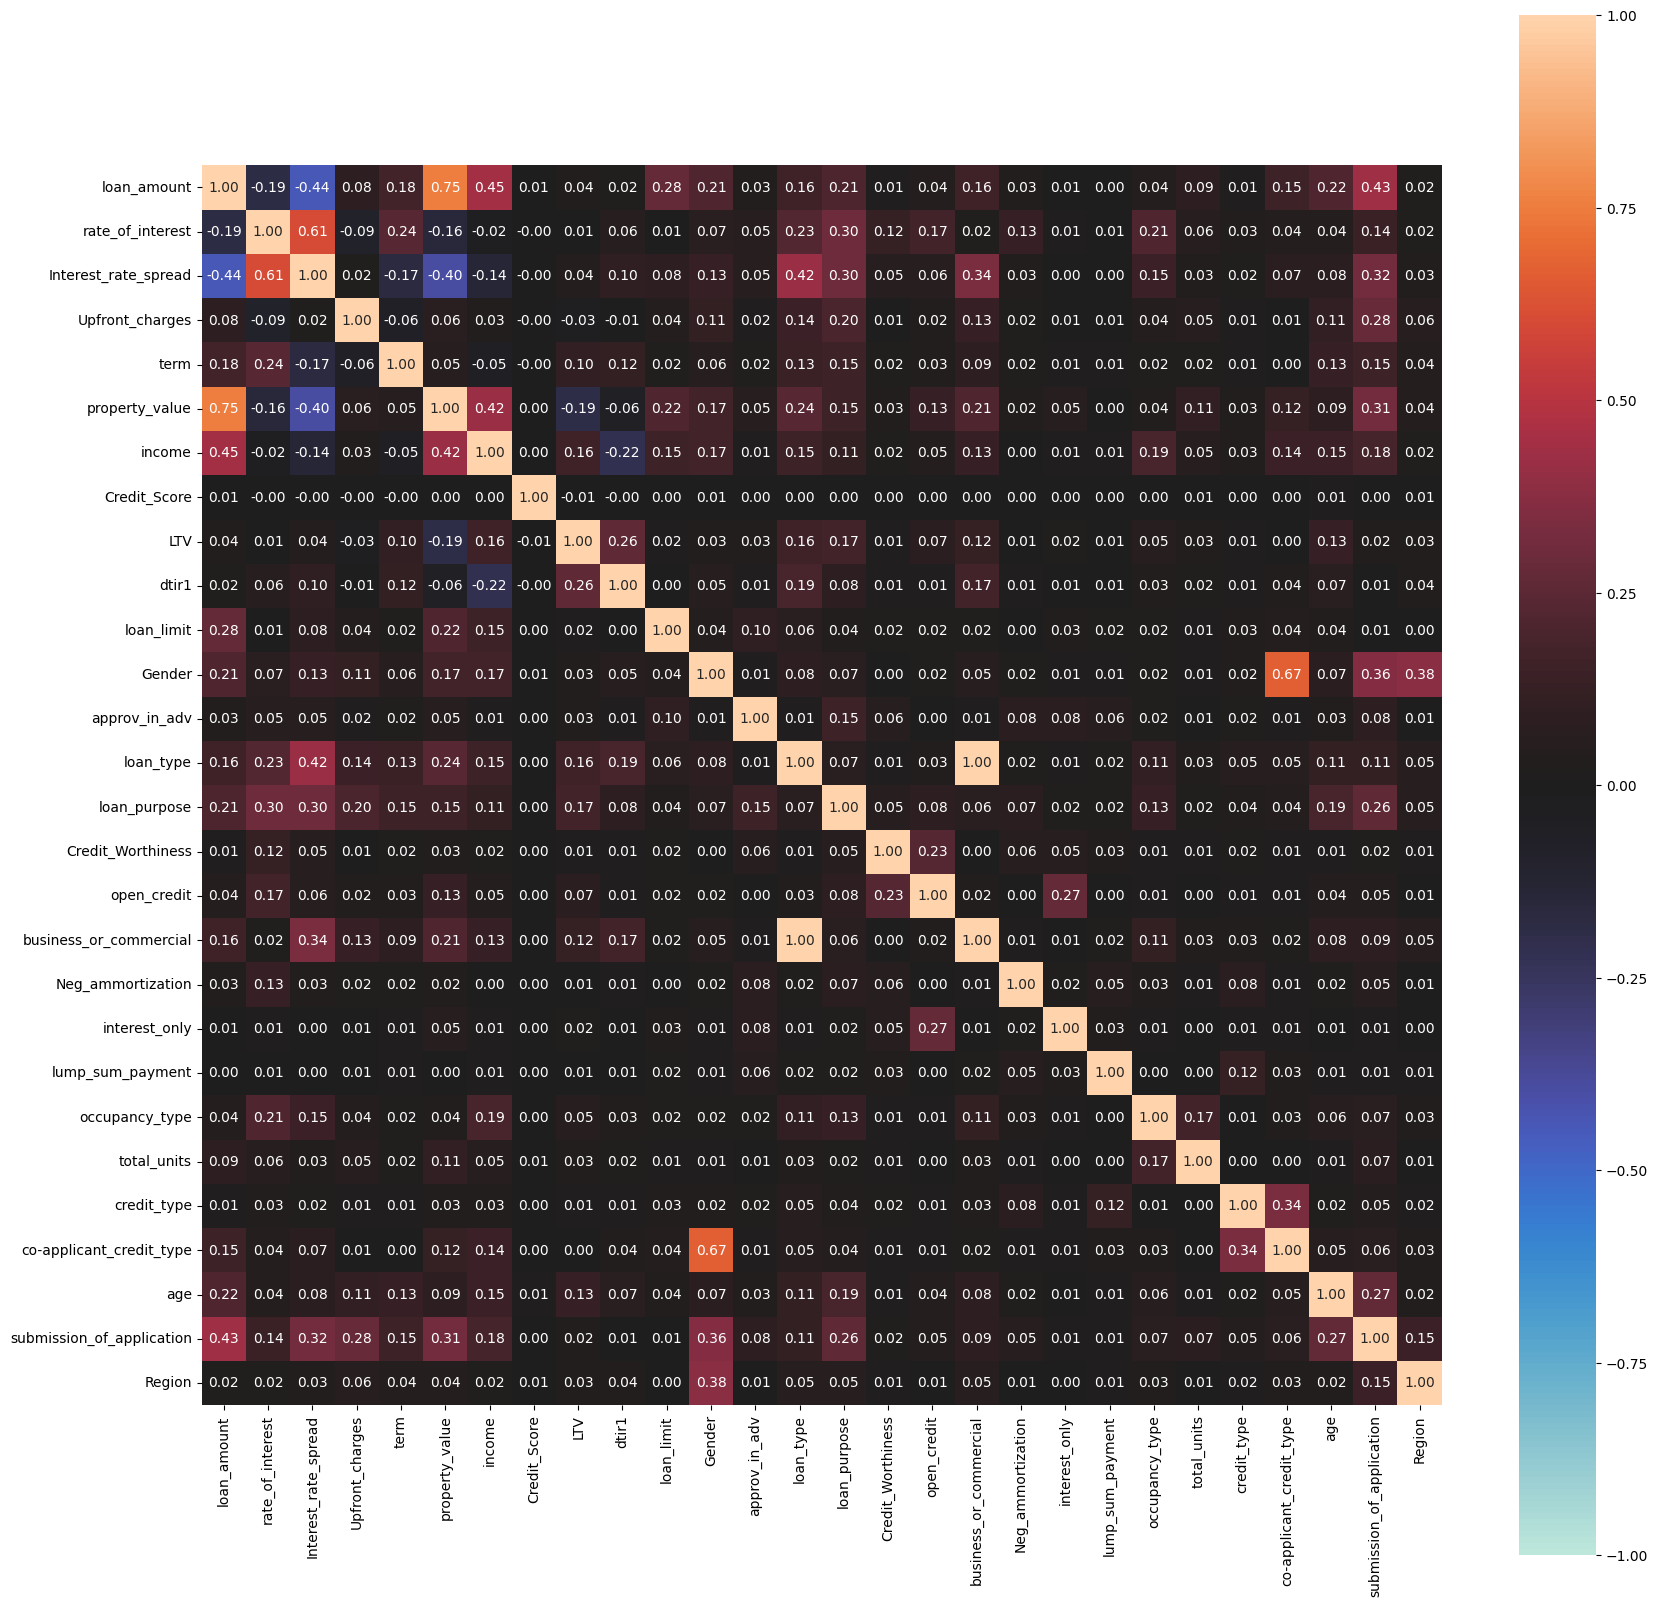

In [18]:
from dython.nominal import associations

_ = associations(X_train, figsize=(20, 20), cbar=True)

### Probléme de colinéarité parfaite (>0.9) !

In [19]:
print(f"Corrélation entre 'business_or_commercial' et 'loan_type' : 0.9999957959788537")
print("==> Corrélation Parfaite\n")
print("loan_type : 0.0938 (p-value: 3.5 x 10^{-285})")
print('business_or_commercial : 0.0925 (p-value: 9.1 x 10^{-279})')
print("==> On supprime la variable 'business_or_commercial'.")

X_train = X_train.drop(columns=['business_or_commercial'])

drop_col += ['business_or_commercial']

Corrélation entre 'business_or_commercial' et 'loan_type' : 0.9999957959788537
==> Corrélation Parfaite

loan_type : 0.0938 (p-value: 3.5 x 10^{-285})
business_or_commercial : 0.0925 (p-value: 9.1 x 10^{-279})
==> On supprime la variable 'business_or_commercial'.


### Variables "Inutiles" ( faible Corrélation + forte P-Value )

À ce stade, nous avons choisi de conserver l'ensemble des variables. En effet, bien que certaines présentent une corrélation linéaire faible, des modèles non linéaires comme le Random Forest ou XGBoost sont capables de capturer des interactions complexes et des relations non-linéaires que les tests statistiques classiques ne décèlent pas.

### For Numerical Features (ANOVA F-test)

In [20]:
import pandas as pd
from sklearn.feature_selection import f_classif
import numpy as np

# 1. Identify numerical columns from the current X_train
# We exclude 'mensualite' if we want to check against the original set,
# but since it's in X_train, we use X_train and y_train to match indices.
num_cols = X_train.select_dtypes(include=['number']).columns

# 2. Compute ANOVA F-value and p-value using the processed training data
f_scores, p_values = f_classif(X_train[num_cols], y_train)

# 3. Create a summary table
anova_stats = pd.DataFrame({
    'Feature': num_cols,
    'F-Score': f_scores,
    'p-value': p_values
}).sort_values(by='F-Score', ascending=False)

print("--- ANOVA Statistics (Numerical Features) ---")
display(anova_stats)

--- ANOVA Statistics (Numerical Features) ---


,Feature,F-Score,p-value
9,dtir1,493.591895,3.935115e-109
6,income,467.884176,1.466779e-103
5,property_value,203.325963,4.286755e-46
0,loan_amount,182.507295,1.474704e-41
8,LTV,75.954273,2.939438e-18
2,Interest_rate_spread,60.859907,6.177885e-15
1,rate_of_interest,5.307766,2.123228e-02
3,Upfront_charges,2.455951,1.170829e-01
7,Credit_Score,1.160560,2.813517e-01
4,term,0.386234,5.342870e-01


### for Categorical Features (Chi-Square Test)

In [21]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import OrdinalEncoder

# 1. Identify categorical columns in X_train
cat_cols = X_train_2.select_dtypes(include=['object', 'category']).columns

# 2. Chi-Square requires numerical input. We temporarily encode categories.
# We use X_train_2 (raw categories) and handle missing values for the test
temp_df = X_train_2[cat_cols].fillna("UNKNOWN")
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(temp_df)

# 3. Compute Chi-Square scores
chi_scores, chi_p_values = chi2(X_encoded, y_train)

# 4. Create a summary table
chi_stats = pd.DataFrame({
    'Feature': cat_cols,
    'Chi2-Score': chi_scores,
    'p-value': chi_p_values
}).sort_values(by='Chi2-Score', ascending=False)

print("\n--- Chi-Square Statistics (Categorical Features) ---")
display(chi_stats)


--- Chi-Square Statistics (Categorical Features) ---


,Feature,Chi2-Score,p-value
15,credit_type,1593.118612,0.000000e+00
16,co-applicant_credit_type,1225.174971,2.061212e-268
3,loan_type,391.701413,3.527603e-87
19,Region,388.659902,1.620389e-86
17,age,385.540214,7.740914e-86
1,Gender,218.186952,2.248345e-49
18,submission_of_application,211.765924,5.657164e-48
7,business_or_commercial,140.850336,1.734877e-32
8,Neg_ammortization,139.586598,3.278054e-32
5,Credit_Worthiness,132.981575,9.125479e-31


## QQs Visualisations

In [22]:
# Création d'un dataset temporaire pour la visualisation
import seaborn as sns

train_eda = X_train.copy()
train_eda['Status'] = y_train.values

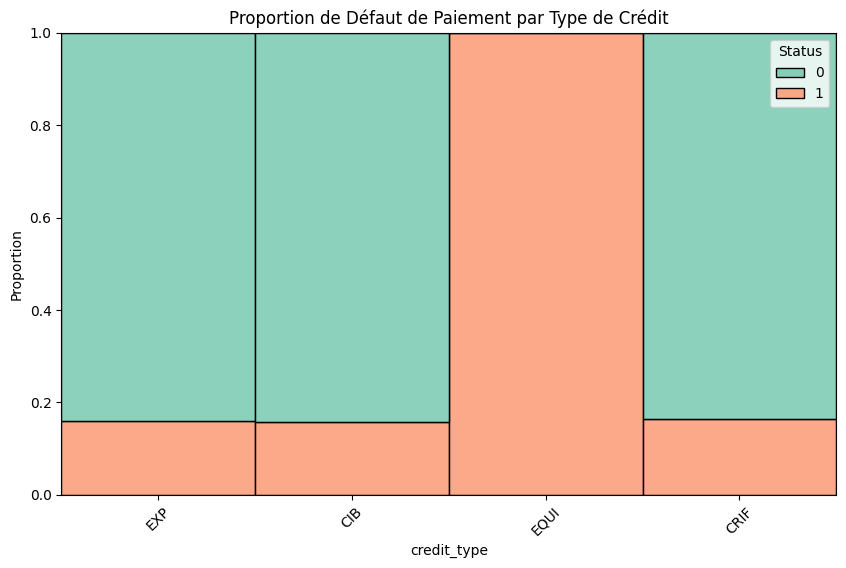

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(data=train_eda, x='credit_type', hue='Status', multiple="fill", palette='Set2')
plt.title("Proportion de Défaut de Paiement par Type de Crédit")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

In [24]:
X_train['credit_type'].value_counts()

credit_type
CIB     38567
CRIF    35111
EXP     33100
EQUI    12158
Name: count, dtype: int64

- CIB (Credit Information Bureau) : Un bureau de données qui centralise l'historique de crédit des emprunteurs pour évaluer leur solvabilité avant l'octroi d'un prêt.

- CRIF (Centrale de Risques Financiers) : Un système international spécialisé dans la gestion du risque de crédit et les solutions de Business Information pour le secteur bancaire.

- EXP (Experian) : L'un des trois plus grands bureaux de crédit mondiaux, fournissant des scores de risque basés sur l'historique de paiement et l'endettement.

- EQUI (Equifax) : Une agence globale d'évaluation du crédit qui regroupe les données financières pour produire des rapports de solvabilité utilisés par les prêteurs.

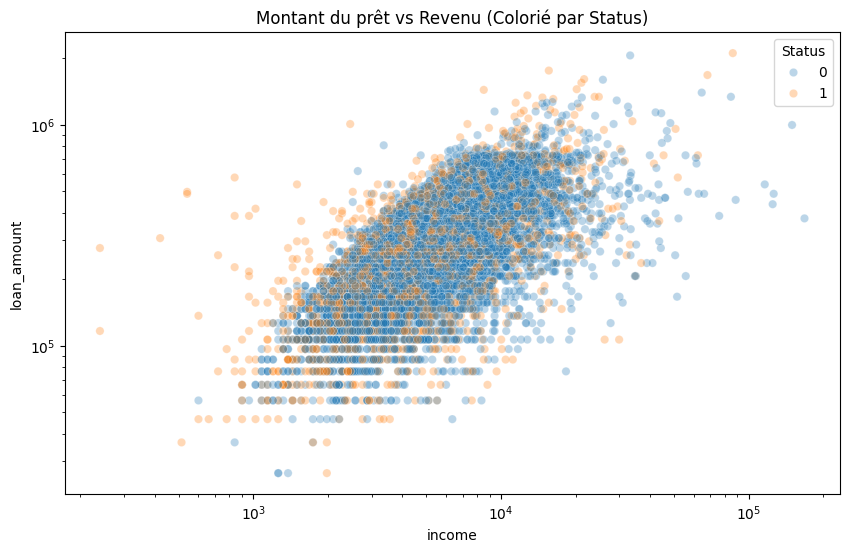

In [25]:
plt.figure(figsize=(10, 6))
# On utilise un échantillon si le dataset est trop gros pour éviter que les points ne se chevauchent trop
sns.scatterplot(data=train_eda.sample(min(10000, len(train_eda))),
                x='income', y='loan_amount', hue='Status', alpha=0.3)
plt.title("Montant du prêt vs Revenu (Colorié par Status)")
plt.xscale('log') # Souvent nécessaire pour l'argent
plt.yscale('log')
plt.show()

## Gestion des Attributs Textuels et Catégoriels

### Feature Engineering

Nous créons de nouvelles variables à partir de celles existantes pour enrichir le jeu de données et potentiellement améliorer la capacité prédictive de nos modèles. Par exemple, le ratio `mensualite` (montant du prêt / durée du prêt) peut être un indicateur clé de la capacité de remboursement. Nous allons également regrouper les durées de prêt (`term`) en catégories (court, moyen, long terme) pour simplifier la variable et capturer des relations non-linéaires.

In [26]:
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("Modalitées des variables catégoriels")

X_train.select_dtypes(exclude=['float64', 'int64']).nunique()

Modalitées des variables catégoriels


loan_limit                   2
Gender                       4
approv_in_adv                2
loan_type                    3
loan_purpose                 4
Credit_Worthiness            2
open_credit                  2
Neg_ammortization            2
interest_only                2
lump_sum_payment             2
occupancy_type               3
total_units                  4
credit_type                  4
co-applicant_credit_type     2
age                          7
submission_of_application    2
Region                       4
dtype: int64

### La stratégie d'encodage

In [27]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

ordinal_encoder = OrdinalEncoder()
onehot_encoder =OneHotEncoder(sparse_output=False, handle_unknown='ignore')

all_cat = X_train.select_dtypes(exclude=['float64', 'int64']).columns.tolist()

ordinal_feat = ['age','Credit_Worthiness']
onehot_feat = [col for col in all_cat if col not in ordinal_feat]

X_train_ohe = pd.DataFrame(
    onehot_encoder.fit_transform(X_train[onehot_feat]),
    columns=onehot_encoder.get_feature_names_out(onehot_feat),
    index=X_train.index
)
X_train_ord = pd.DataFrame(
    ordinal_encoder.fit_transform(X_train[ordinal_feat]),
    columns=ordinal_feat,
    index=X_train.index
)

X_train_num = X_train.select_dtypes(include=['float64', 'int64'])
X_train = pd.concat([X_train_num, X_train_ohe, X_train_ord], axis=1)

print(f"Dimensions finales : {X_train.shape}")
type(X_train)


Dimensions finales : (118936, 54)


pandas.DataFrame

## Distrubition des variables numériques

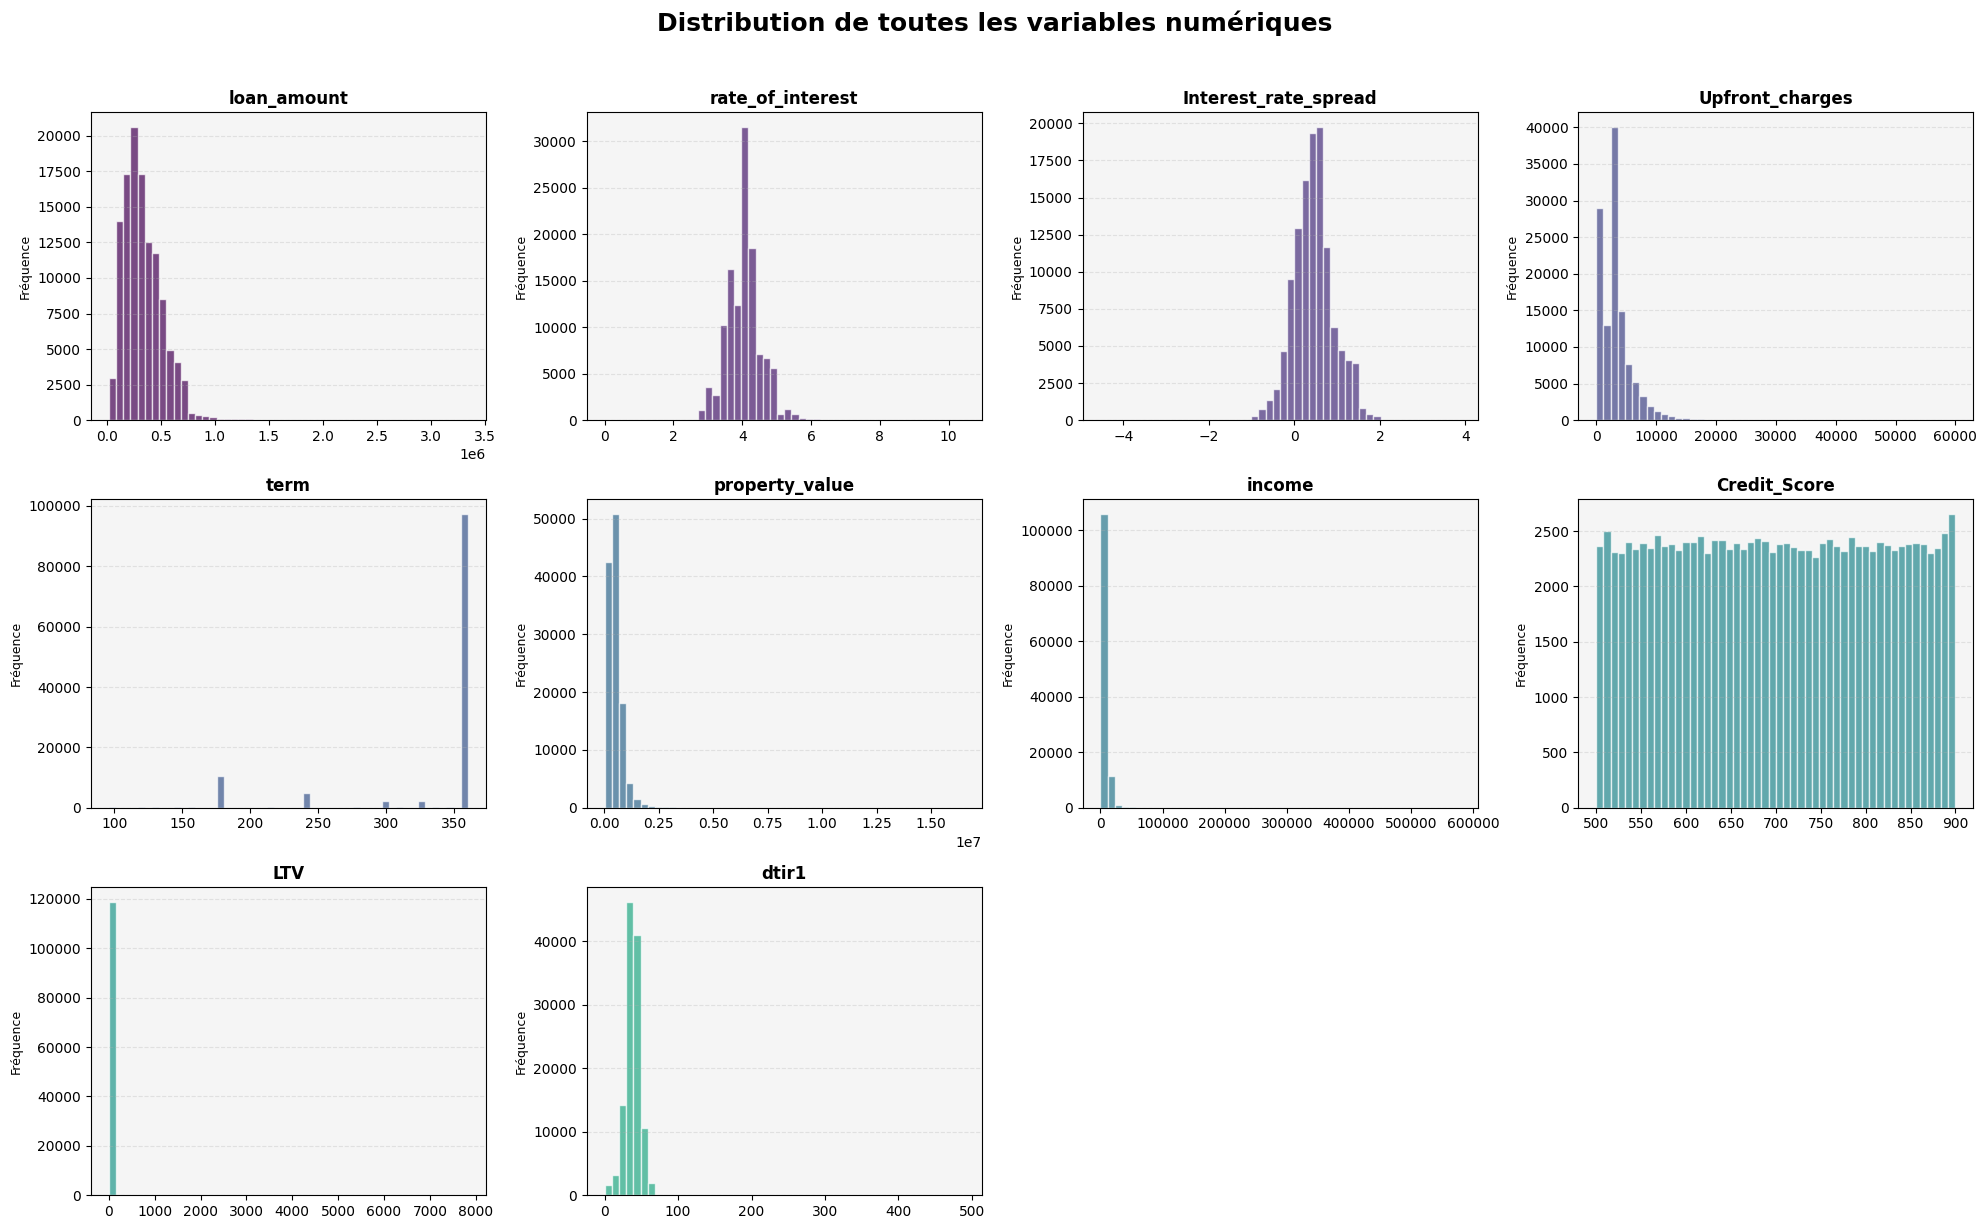

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import math

# 1. Sélectionner uniquement les colonnes numériques
cols_num = num_cols
n_cols = len(cols_num)

# 2. Calculer le nombre de lignes/colonnes pour la grille
n_subplot_cols = 4
n_subplot_rows = (n_cols + n_subplot_cols - 1) // n_subplot_cols

# 3. Créer UNE SEULE figure
fig, axes = plt.subplots(n_subplot_rows, n_subplot_cols, figsize=(20, 4 * n_subplot_rows))
axes = axes.flatten() # Aplatir pour itérer facilement

# 4. Palette de couleurs (une couleur différente par plot)
colors = plt.cm.viridis(np.linspace(0, 0.6, n_cols))

# 5. Boucle pour tracer chaque histogramme manuellement
for i, col in enumerate(cols_num):
    ax = axes[i]
    X_train[col].hist(ax=ax, bins=50, color=colors[i], edgecolor='white', alpha=0.7, grid=False)

    # Personnalisation
    ax.set_title(col, fontweight='bold', fontsize=12)
    ax.set_facecolor('#f5f5f5')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylabel('Fréquence', fontsize=9)

# 6. Supprimer les subplots vides si nécessaire
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution de toutes les variables numériques', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Distrubition des variables catégoriques

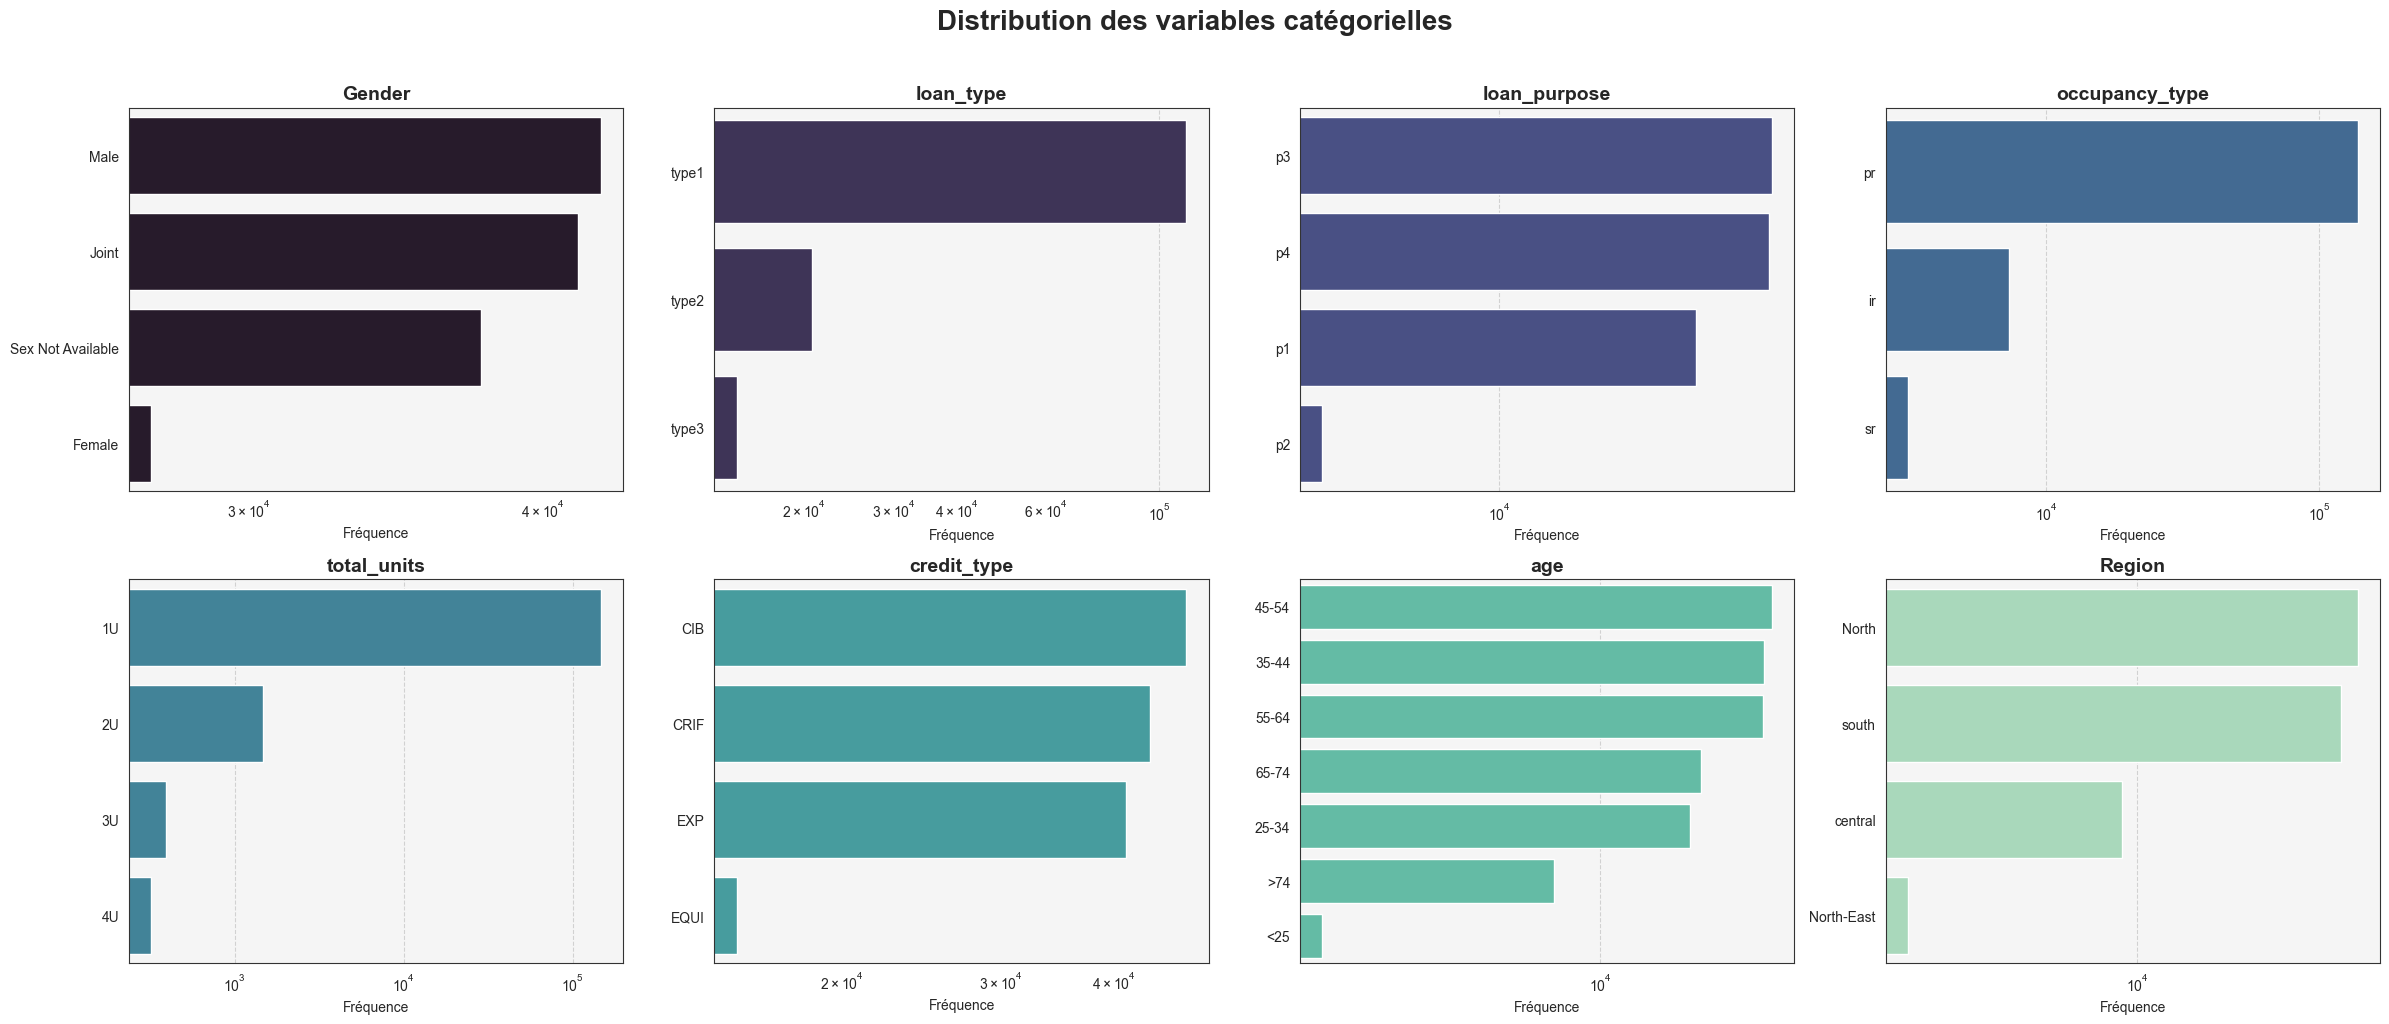

In [29]:
# 1. Filter columns
filtered_cat_cols = [col for col in cat_cols if df[col].nunique() >= 3]

# 2. Setup grid
cols_per_row = 4 # Matching the 4 columns in your image
num_plots = len(filtered_cat_cols)
num_rows = math.ceil(num_plots / cols_per_row)

# Set the overall style
sns.set_style("white")
plt.figure(figsize=(24, num_rows * 5))
plt.suptitle('Distribution des variables catégorielles', fontsize=20, fontweight='bold', y=1.02)

colors = sns.color_palette("mako", n_colors=num_plots)

for i, col in enumerate(filtered_cat_cols):
    ax = plt.subplot(num_rows, cols_per_row, i + 1)

    sns.countplot(
        data=df,
        y=col,
        order=df[col].value_counts().index,
        color=colors[i],
        edgecolor='white',
        ax=ax
    )
    ax.set_title(col, fontweight='bold', fontsize=14)
    ax.set_facecolor('#f5f5f5') # Light grey background
    ax.grid(axis='x', alpha=0.3, linestyle='--', color='grey')
    ax.set_xlabel('Fréquence', fontsize=10)
    ax.set_ylabel('')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#333333')
        spine.set_linewidth(0.8)

    ax.set_xscale("log")

plt.tight_layout()
plt.show()

### transformation

<Figure size 2000x1500 with 0 Axes>

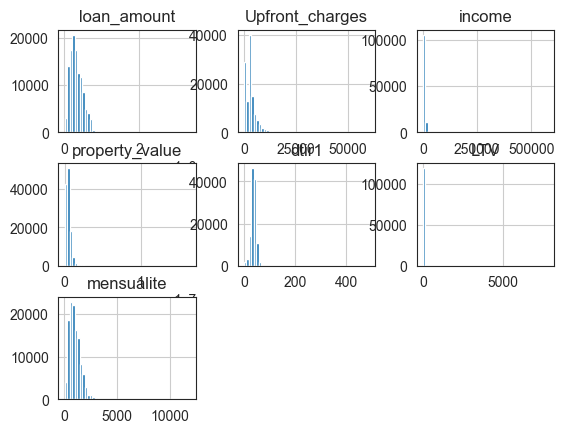

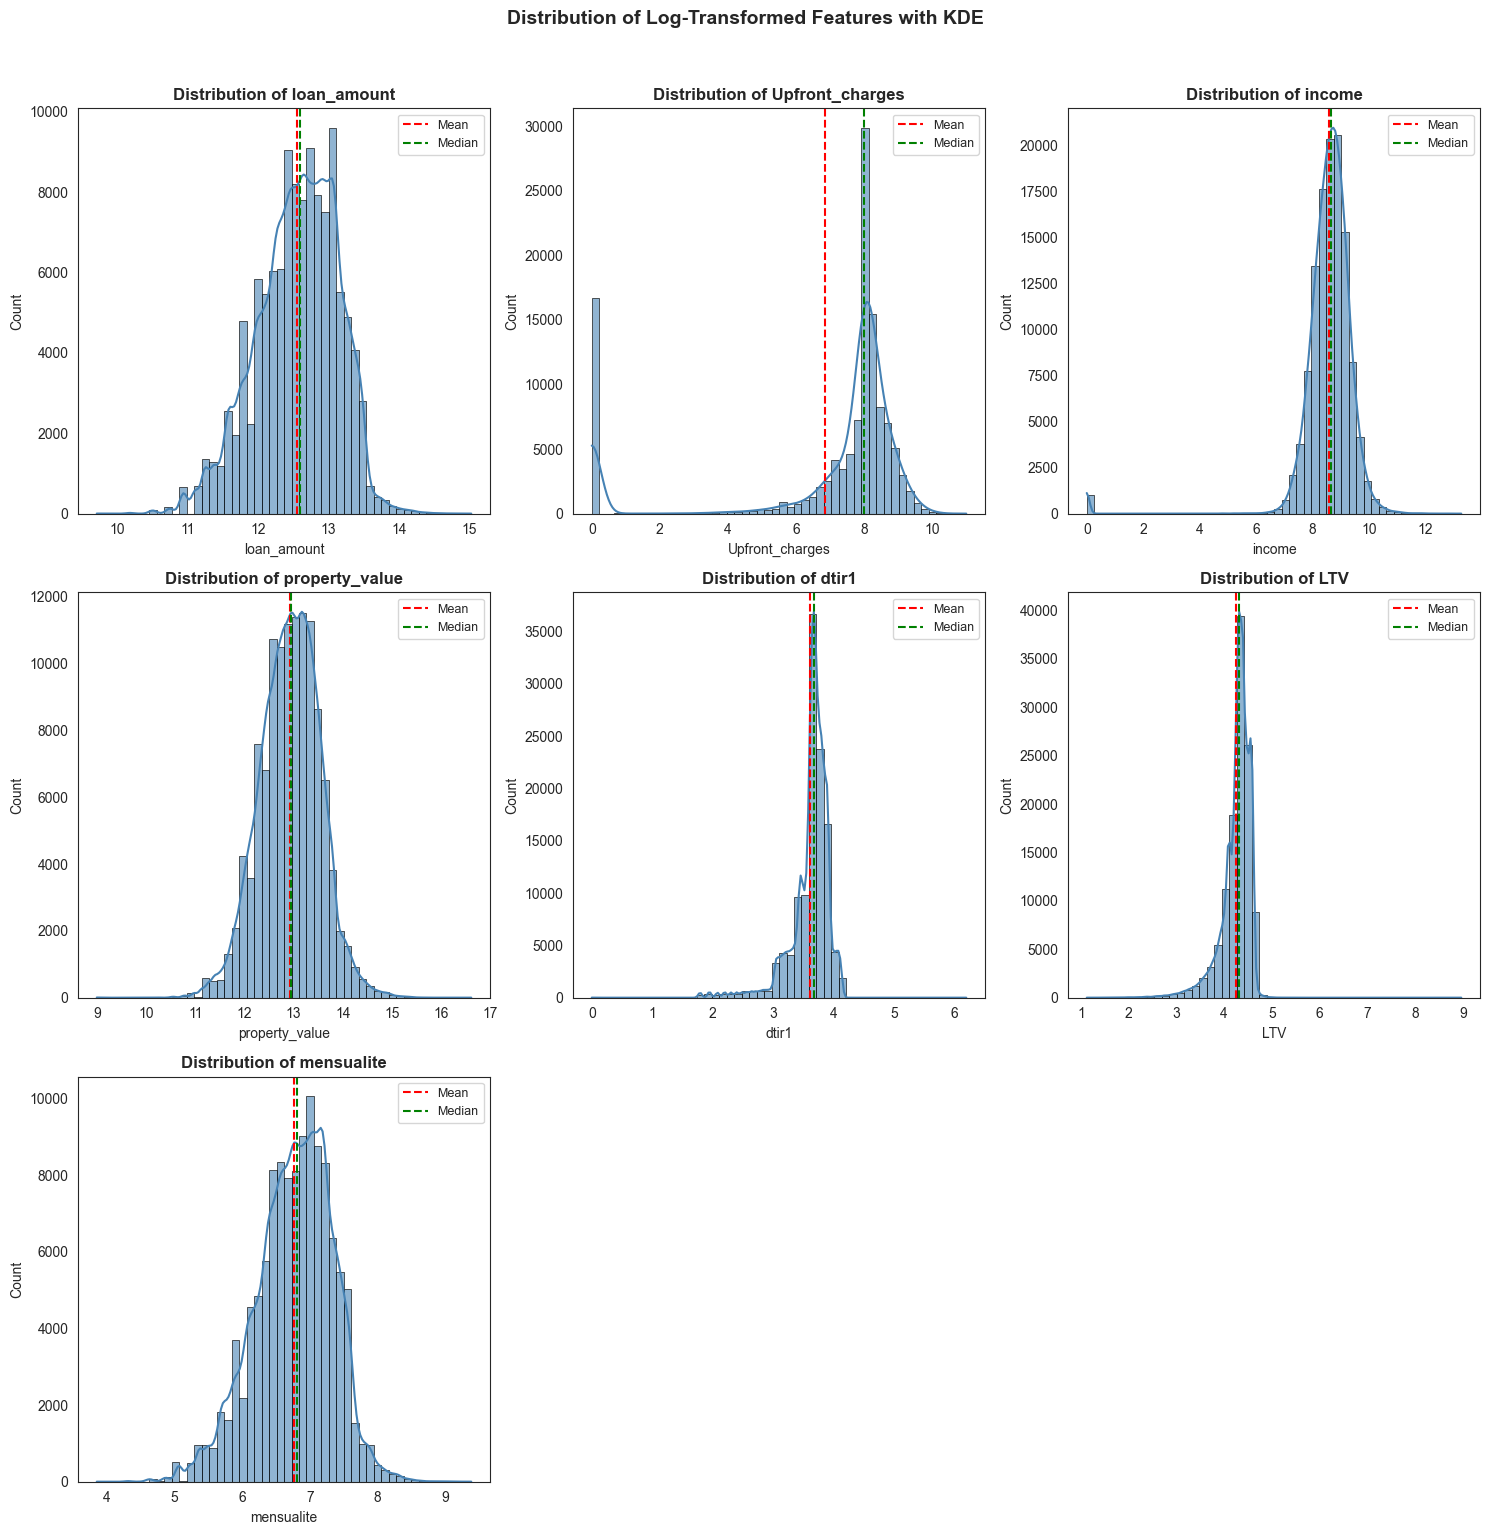

In [30]:
from sklearn.preprocessing import FunctionTransformer

X_train['mensualite'] = X_train['loan_amount'] / X_train['term']

log_trans_col = ['loan_amount','Upfront_charges','income','property_value','dtir1','LTV','mensualite']

plt.figure(figsize=(20, 15))
X_train[log_trans_col].hist(bins = 50)
plt.show()

log_transformer = FunctionTransformer(np.log1p, inverse_func=np.expm1)

X_train[log_trans_col] = log_transformer.fit_transform(X_train[log_trans_col])



""" -------- Code for better visualization -------- """


n_features = len(log_trans_col)
n_cols_grid = 3
n_rows_grid = math.ceil(n_features / n_cols_grid)

# 3. Création de la figure qui s'adapte
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(15, 5 * n_rows_grid))
axes = axes.ravel()

# 4. Ta boucle intacte
for idx, col in enumerate(log_trans_col):
    sns.histplot(data=X_train, x=col, bins=50, kde=True, ax=axes[idx],
                 color='steelblue', edgecolor='black', alpha=0.6)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].axvline(x=X_train[col].mean(), color='red', linestyle='--',
                      linewidth=1.5, label='Mean')
    axes[idx].axvline(x=X_train[col].median(), color='green', linestyle='--',
                      linewidth=1.5, label='Median')
    axes[idx].legend(fontsize=9)

# 5. On efface les cases vides en trop (les cases 8 et 9)
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribution of Log-Transformed Features with KDE', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Pour la variable "term"

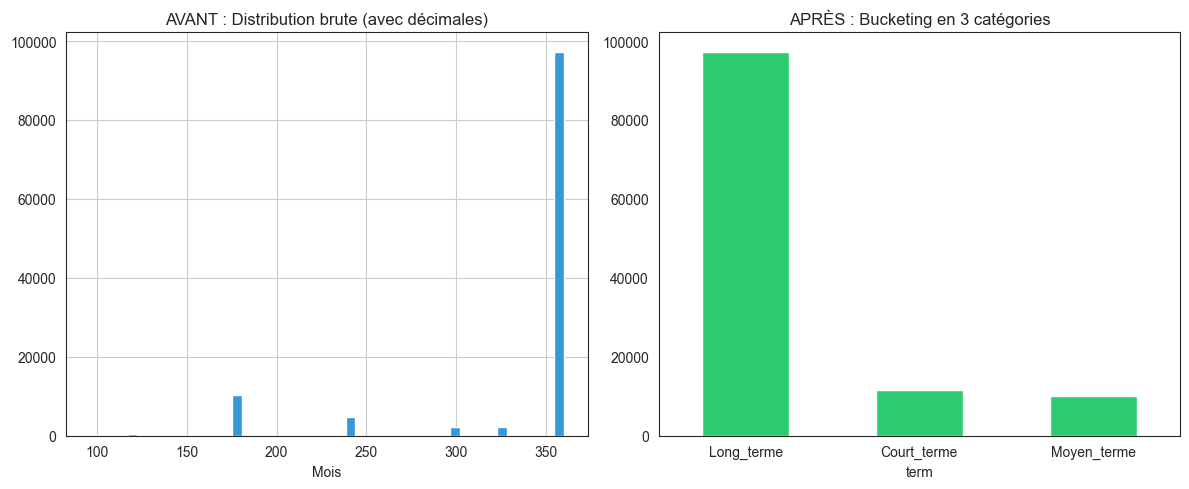

In [31]:
def bucketize_term(X):
    bins = [0, 180, 359, np.inf]
    labels = ['Court_terme', 'Moyen_terme', 'Long_terme']

    X_binned = pd.cut(X.iloc[:, 0], bins=bins, labels=labels).astype(str).to_frame()
    return X_binned

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
X_train['term'].hist(bins=50, color='#3498db')
plt.title("AVANT : Distribution brute (avec décimales)")
plt.xlabel("Mois")

term_transf = FunctionTransformer(bucketize_term)
X_train["term"] = term_transf.fit_transform(X_train[['term']])

plt.subplot(1, 2, 2)
X_train['term'].value_counts().plot(kind='bar', color='#2ecc71')
plt.title("APRÈS : Bucketing en 3 catégories")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [32]:
term_ohe = onehot_encoder.fit_transform(X_train[['term']])
term_col = onehot_encoder.get_feature_names_out(['term'])

term_encoded = pd.DataFrame(term_ohe, columns=term_col, index=X_train.index)
X_train = pd.concat([X_train, term_encoded], axis=1)
X_train = X_train.drop(columns=['term'])

print('Encodage terminé !')


Encodage terminé !


### Feature Scaling

### Feature Scaling

La standardisation est cruciale pour les modèles sensibles à l'échelle des variables (comme la régression logistique ou les SVM). Elle permet de s'assurer que toutes les variables numériques contribuent équitablement au modèle, en transformant leurs distributions pour avoir une moyenne de 0 et un écart-type de 1.

In [33]:
from sklearn.preprocessing import StandardScaler

cols_num.remove("term")

scaler = StandardScaler()
X_train[cols_num] = scaler.fit_transform(X_train[cols_num])

print("Scaling terminé !")


Scaling terminé !


## Résultat finale !

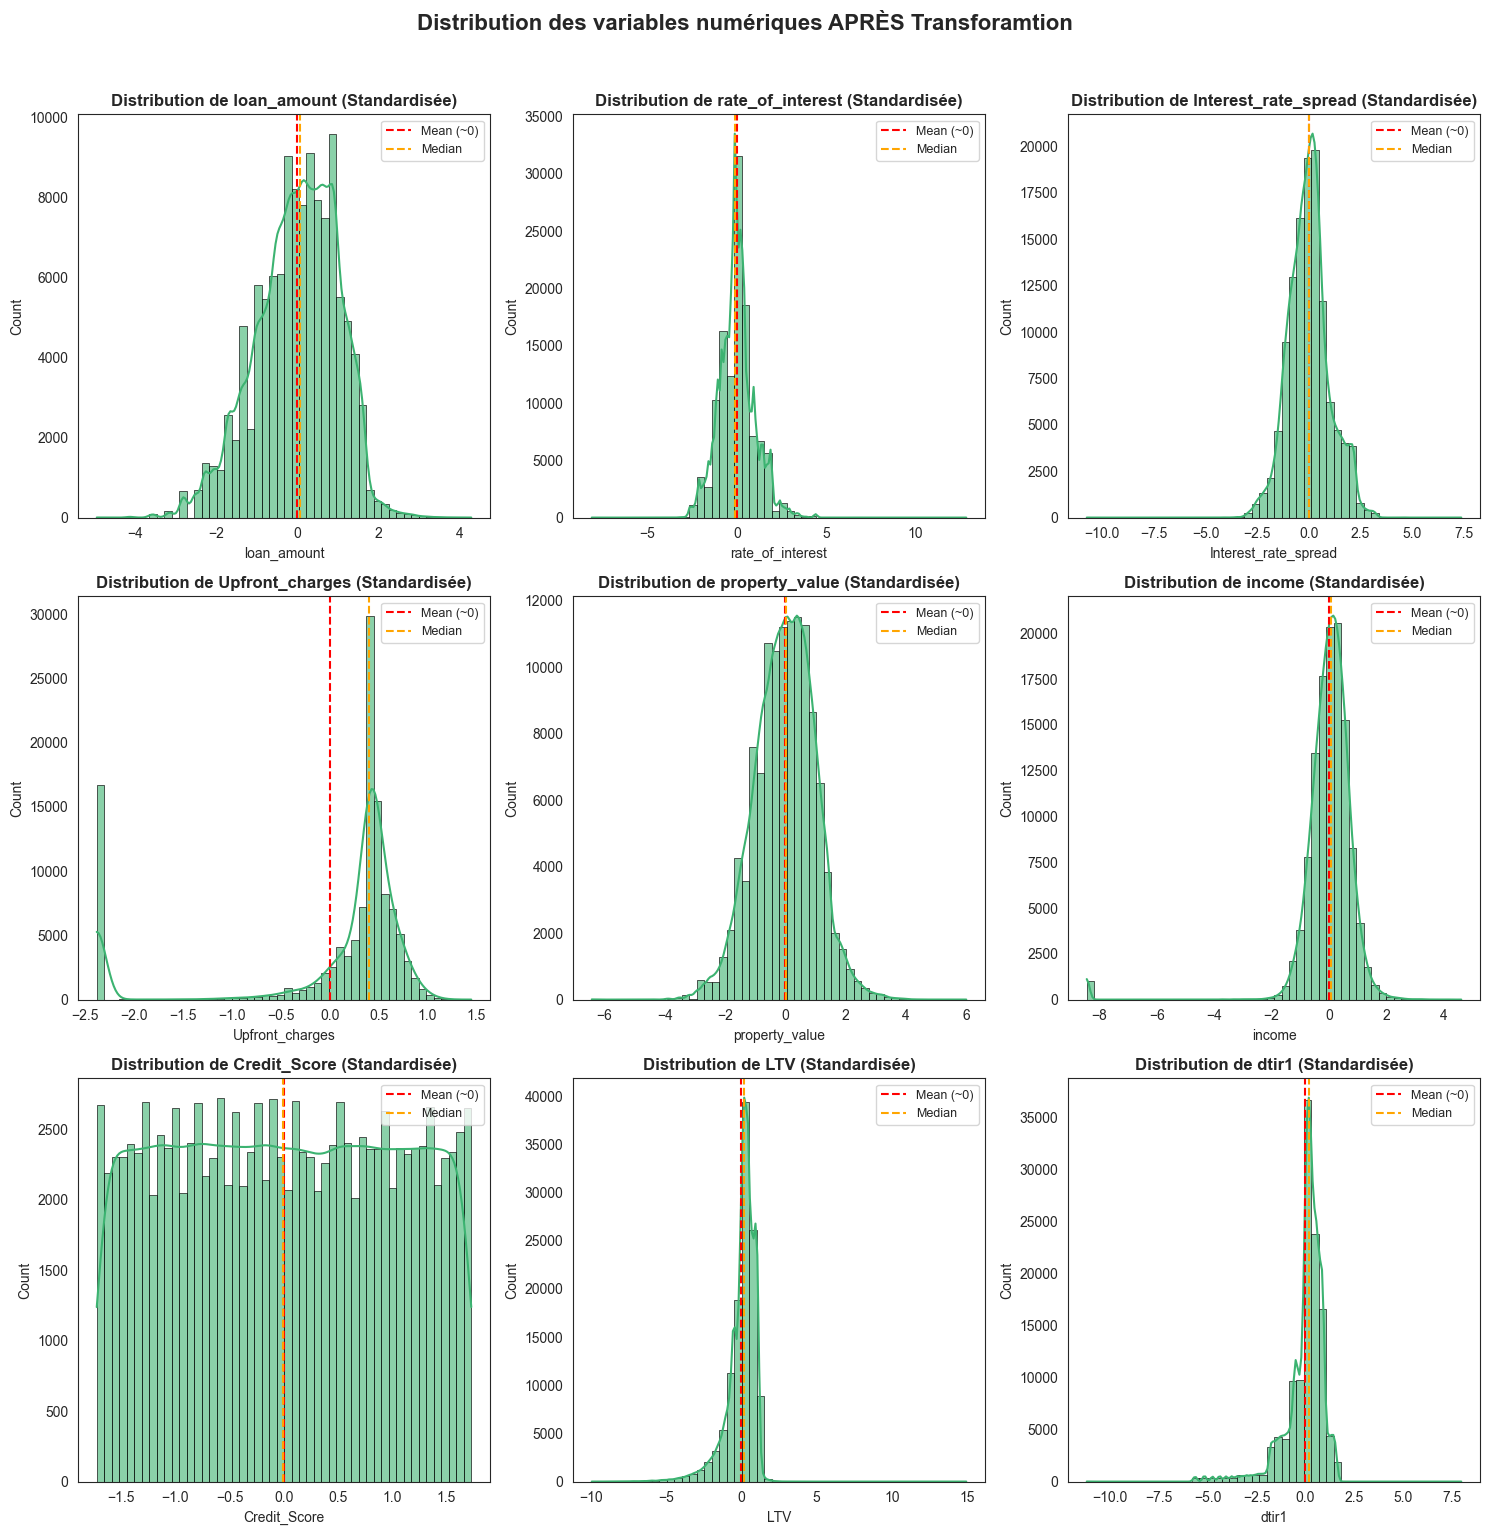

In [34]:
# 1. Calcul automatique de la taille de la grille selon le nombre de colonnes
n_features = len(cols_num)
n_cols_grid = 3
n_rows_grid = math.ceil(n_features / n_cols_grid)

# 2. Création de la figure (la hauteur s'adapte au nombre de lignes)
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(15, 5 * n_rows_grid))
axes = axes.ravel() # Aplatit la grille pour pouvoir boucler dessus facilement

# 3. Boucle sur les colonnes numériques
for idx, col in enumerate(cols_num):
    # Tracé de l'histogramme avec KDE
    sns.histplot(data=X_train, x=col, bins=50, kde=True, ax=axes[idx],
                 color='mediumseagreen', edgecolor='black', alpha=0.6)

    axes[idx].set_title(f'Distribution de {col} (Standardisée)', fontsize=12, fontweight='bold')

    # Ajout des lignes de Moyenne et Médiane
    axes[idx].axvline(x=X_train[col].mean(), color='red', linestyle='--',
                      linewidth=1.5, label='Mean (~0)')
    axes[idx].axvline(x=X_train[col].median(), color='orange', linestyle='--',
                      linewidth=1.5, label='Median')
    axes[idx].legend(fontsize=9)

# 4. Nettoyage : cacher les cases vides si le nombre de features n'est pas un multiple de 3
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

# 5. Titre global et affichage
plt.suptitle('Distribution des variables numériques APRÈS Transforamtion', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Pipeline de Preprocessing

In [35]:
import warnings
warnings.filterwarnings('ignore')

In [36]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_transformer
from sklearn import set_config


set_config(transform_output="pandas")

# Helper functions for the pipeline
def calculate_mensualite(X):
    # Calculation: loan_amount / term
    res = pd.DataFrame(X.iloc[:, 0] / X.iloc[:, 1], columns=["mensualite"])
    return res

def bucket_term(X):
    bins = [0, 180, 359, np.inf]
    labels = ['Court_terme', 'Moyen_terme', 'Long_terme']
    return pd.DataFrame(pd.cut(X.iloc[:, 0], bins=bins, labels=labels).astype(str), columns=["term"])

# Define feature groups based on raw data
log_cols = ['loan_amount', 'income', 'property_value', 'dtir1', 'LTV']
num_standard_cols = ['Credit_Score']
ordinal_feat = ['age', 'Credit_Worthiness']
cat_nominales = ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'open_credit', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'occupancy_type', 'total_units', 'credit_type', 'co-applicant_credit_type', 'submission_of_application', 'Region']

# Pipelines for individual features
mensualite_pipeline = make_pipeline(
    FunctionTransformer(calculate_mensualite),
    FunctionTransformer(np.log1p),
    StandardScaler()
)

term_pipeline = make_pipeline(
    FunctionTransformer(bucket_term),
    OneHotEncoder(sparse_output=False, handle_unknown="ignore")
)

# Second Stage: Feature Engineering and Scaling
# We set verbose_feature_names_out=False to keep original column names from the previous step
preprocessing = ColumnTransformer([
    ("mensualite", mensualite_pipeline, ["loan_amount", "term"]),
    ("log_num", make_pipeline(FunctionTransformer(np.log1p), StandardScaler()), log_cols),
    ("term_bucket", term_pipeline, ["term"]),
    ("num_standard", StandardScaler(), num_standard_cols),
    ("ordinal", OrdinalEncoder(), ordinal_feat),
    ("categorical", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_nominales)
], remainder="drop", verbose_feature_names_out=False)

# First Stage: Imputation
impute_step = ColumnTransformer([
    ('num_impute', IterativeImputer(max_iter=10, random_state=42, min_value=0), log_cols + num_standard_cols + ['term']),
    ('cat_impute', SimpleImputer(strategy='most_frequent'), ordinal_feat + cat_nominales)
], remainder='drop', verbose_feature_names_out=False)

# Complete pipeline
full_pipeline = make_pipeline(
    impute_step,
    preprocessing
)

## SMOTE

### Gestion du Déséquilibre des Classes avec SMOTE

La variable cible `Status` (défaut de paiement) est très déséquilibrée, avec une nette majorité d'emprunteurs remboursant leur prêt. Pour éviter que nos modèles ne soient biaisés et ne prédisent toujours la classe majoritaire, nous utilisons **SMOTE (Synthetic Minority Over-sampling Technique)**. Cette technique crée des échantillons synthétiques de la classe minoritaire (défaut de paiement) en interpolant les caractéristiques des échantillons existants, équilibrant ainsi la distribution des classes dans notre jeu d'entraînement.

In [38]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Avant SMOTE :")
print(y_train.value_counts())
print("\nAprès SMOTE :")
print(y_train_resampled.value_counts())

Avant SMOTE :
Status
0    89625
1    29311
Name: count, dtype: int64

Après SMOTE :
Status
0    89625
1    89625
Name: count, dtype: int64


## Training

In [39]:
X_train_resampled = X_train_resampled.drop(columns=["Interest_rate_spread","Upfront_charges","rate_of_interest"])

X_train = X_train.drop(columns=["Interest_rate_spread","Upfront_charges","rate_of_interest"])


In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report

ling_reg = LinearRegression()
ling_reg.fit(X_train_resampled, y_train_resampled)

y_train_pred = ling_reg.predict(X_train_resampled)
y_train_pred_class = (y_train_pred >= 0.5).astype(int)

print("\n--- Rapport de Classification : Linear Regression (Train) ---")
print(classification_report(y_train_resampled, y_train_pred_class))


--- Rapport de Classification : Linear Regression (Train) ---
              precision    recall  f1-score   support

           0       0.69      0.93      0.79     89625
           1       0.89      0.59      0.71     89625

    accuracy                           0.76    179250
   macro avg       0.79      0.76      0.75    179250
weighted avg       0.79      0.76      0.75    179250



### Interprétation des Résultats de la Régression Linéaire (Train)

Ce rapport de classification présente les performances du modèle de régression linéaire sur les données d'entraînement rééchantillonnées par SMOTE. Les métriques clés sont :

*   **Précision (Precision)** : Proportion des prédictions positives qui étaient correctes. Pour la classe 0 (pas de défaut), elle est de 0.70, et pour la classe 1 (défaut), elle est de 0.89. Cela signifie que lorsqu'il prédit un défaut, le modèle est souvent correct.
*   **Rappel (Recall)** : Proportion des cas réels positifs qui ont été correctement identifiés. Pour la classe 0, il est très élevé (0.93), mais pour la classe 1, il est de 0.59. Le modèle a du mal à détecter tous les cas de défauts réels.
*   **F1-Score** : Moyenne harmonique de la précision et du rappel. Il offre un bon équilibre entre les deux métriques. Les scores F1 sont de 0.79 pour la classe 0 et 0.71 pour la classe 1.
*   **Accuracy** : Proportion globale des prédictions correctes (0.76).

**Constat :** Le modèle a une meilleure capacité à identifier correctement les non-défauts et est assez précis lorsqu'il prédit un défaut. Cependant, il manque de rappel pour la classe minoritaire (défaut), ce qui est un point à améliorer.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_reg = LogisticRegression(penalty='l1',solver='saga',C = 100)
log_reg.fit(X_train_resampled, y_train_resampled)

y_train_pred = log_reg.predict(X_train_resampled)


print("\n--- Rapport de Classification : Logistic Regression (Train) ---")
print(classification_report(y_train_resampled, y_train_pred_class))


--- Rapport de Classification : Logistic Regression (Train) ---
              precision    recall  f1-score   support

           0       0.69      0.93      0.79     89625
           1       0.89      0.59      0.71     89625

    accuracy                           0.76    179250
   macro avg       0.79      0.76      0.75    179250
weighted avg       0.79      0.76      0.75    179250



### Interprétation des Résultats de la Régression Logistique (Train)

Similaire à la régression linéaire, le modèle de régression logistique affiche des performances comparables sur les données d'entraînement. Nous observons des métriques qui tendent à favoriser la classe majoritaire (non-défaut) :

*   **Précision (Precision)** : 0.70 pour la classe 0 et 0.89 pour la classe 1.
*   **Rappel (Recall)** : 0.93 pour la classe 0 et 0.59 pour la classe 1.
*   **F1-Score** : 0.79 pour la classe 0 et 0.71 pour la classe 1.
*   **Accuracy** : 0.76.

**Hyperparamètres Utilisés :**
*   `penalty='l1'` : Utilisation de la régularisation L1 (Lasso), qui a tendance à annuler certains coefficients, permettant ainsi une sélection de caractéristiques implicite. C'est utile pour simplifier le modèle et potentiellement réduire le surapprentissage.
*   `solver='saga'` : Un algorithme de résolution robuste et efficace pour les grands ensembles de données, et qui prend en charge les pénalités L1 et L2.
*   `C=100` : Un hyperparamètre inverse de la force de régularisation. Une valeur élevée de C signifie une régularisation faible. Dans ce cas, le modèle est autorisé à s'adapter plus étroitement aux données d'entraînement, ce qui pourrait conduire à un surapprentissage si non contrôlé.

### Sélection de Caractéristiques avec RFE (Recursive Feature Elimination) pour la Régression Logistique

Avant d'affiner les hyperparamètres de la Régression Logistique, nous allons utiliser la **Recursive Feature Elimination (RFE) avec Cross-Validation (RFECV)**. Cette technique permet de sélectionner automatiquement les caractéristiques les plus pertinentes en éliminant récursivement les moins importantes, et en évaluant la performance du modèle à chaque étape grâce à la cross-validation. L'objectif est de trouver un sous-ensemble optimal de caractéristiques qui maximise le F1-score de notre modèle de Régression Logistique, potentiellement en améliorant l'interprétabilité et en réduisant le bruit.

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

# Initialiser un estimateur de Régression Logistique avec les paramètres optimaux trouvés ou par défaut
# Nous utiliserons les paramètres de base pour la sélection de caractéristiques,
# car les hyperparamètres plus poussés seront ajustés par GridSearchCV ensuite.
log_reg_rfe_estimator = LogisticRegression(penalty='l1', solver='saga', C=100, max_iter=2000, random_state=42)

# Initialiser RFECV avec des paramètres ajustés pour une exécution plus rapide
# cv=2 pour la validation croisée (pour la vitesse), step=5 pour éliminer 5 features à chaque itération
rfe = RFECV(estimator=log_reg_rfe_estimator, step=5, cv=2, scoring='f1', n_jobs=-1, verbose=1)

# Appliquer RFECV sur les données d'entraînement rééchantillonnées
rfe.fit(X_train_resampled, y_train_resampled)

print(f"Nombre optimal de caractéristiques : {rfe.n_features_}")
# Note: grid_scores_ is deprecated in scikit-learn >= 1.0, use cv_results_['mean_test_score'] instead if you encounter errors.
print(f"Meilleur score F1 avec ces caractéristiques : {rfe.grid_scores_[rfe.n_features_ - 1]:.4f}")
print(f"Caractéristiques sélectionnées ({rfe.n_features_} au total) :")
selected_features_logreg = list(X_train_resampled.columns[rfe.support_])
for feature in selected_features_logreg:
    print(f"- {feature}")


# Créer un DataFrame avec uniquement les caractéristiques sélectionnées pour la Régression Logistique
X_train_resampled_logreg_rfe = X_train_resampled[selected_features_logreg].copy()

'from sklearn.feature_selection import RFECV\nfrom sklearn.linear_model import LogisticRegression\n\n# Initialiser un estimateur de Régression Logistique avec les paramètres optimaux trouvés ou par défaut\n# Nous utiliserons les paramètres de base pour la sélection de caractéristiques,\n# car les hyperparamètres plus poussés seront ajustés par GridSearchCV ensuite.\nlog_reg_rfe_estimator = LogisticRegression(penalty=\'l1\', solver=\'saga\', C=100, max_iter=2000, random_state=42)\n\n# Initialiser RFECV avec des paramètres ajustés pour une exécution plus rapide\n# cv=2 pour la validation croisée (pour la vitesse), step=5 pour éliminer 5 features à chaque itération\nrfe = RFECV(estimator=log_reg_rfe_estimator, step=5, cv=2, scoring=\'f1\', n_jobs=-1, verbose=1)\n\n# Appliquer RFECV sur les données d\'entraînement rééchantillonnées\nrfe.fit(X_train_resampled, y_train_resampled)\n\nprint(f"Nombre optimal de caractéristiques : {rfe.n_features_}")\n# Note: grid_scores_ is deprecated in scikit

<pre>
Fitting estimator with 54 features.
Fitting estimator with 54 features.
Fitting estimator with 49 features.
Fitting estimator with 49 features.
Fitting estimator with 44 features.
Fitting estimator with 44 features.
Fitting estimator with 39 features.
Fitting estimator with 39 features.
Fitting estimator with 34 features.
Fitting estimator with 34 features.
Fitting estimator with 29 features.
Fitting estimator with 29 features.
Fitting estimator with 24 features.
Fitting estimator with 24 features.
Fitting estimator with 19 features.
Fitting estimator with 19 features.
Fitting estimator with 14 features.
Fitting estimator with 14 features.
Fitting estimator with 9 features.
Fitting estimator with 9 features.
Fitting estimator with 4 features.
Fitting estimator with 4 features.
Nombre optimal de caractéristiques : 54
</pre>

### Interprétation des Résultats de RFECV pour la Régression Logistique

L'analyse RFECV a identifié un sous-ensemble optimal de caractéristiques pour la Régression Logistique.

*   **Nombre Optimal de Caractéristiques** : 54


In [44]:
from sklearn.svm import LinearSVC

svm = LinearSVC(C=1,random_state=42)
svm.fit(X_train_resampled,y_train_resampled)

y_svm_pred = svm.predict(X_train_resampled)

print("\n--- Rapport de Classification : LinearSVC (Train) ---")
print(classification_report(y_train_resampled, y_svm_pred))


--- Rapport de Classification : LinearSVC (Train) ---
              precision    recall  f1-score   support

           0       0.72      0.90      0.80     89625
           1       0.87      0.64      0.74     89625

    accuracy                           0.77    179250
   macro avg       0.79      0.77      0.77    179250
weighted avg       0.79      0.77      0.77    179250



In [45]:
from sklearn.tree import DecisionTreeClassifier

dtc= DecisionTreeClassifier()

dtc.fit(X_train_resampled,y_train_resampled)

y_dt_pred = dtc.predict(X_train_resampled)

print("--- Rapport de Classification : Decision Tree (Train) ---")
print(classification_report(y_train_resampled, y_dt_pred))

--- Rapport de Classification : Decision Tree (Train) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     89625
           1       1.00      1.00      1.00     89625

    accuracy                           1.00    179250
   macro avg       1.00      1.00      1.00    179250
weighted avg       1.00      1.00      1.00    179250



<pre>
---- Tree on test ----
              precision    recall  f1-score   support

           0       0.89      0.63      0.74     22406
           1       0.40      0.76      0.53      7328

    accuracy                           0.66     29734
   macro avg       0.65      0.70      0.63     29734
weighted avg       0.77      0.66      0.69     29734
</pre>

### ==> Overfitting

In [55]:
from sklearn.tree import DecisionTreeClassifier

dtc= DecisionTreeClassifier(
    max_depth=15,            
    min_samples_split=20,   
    min_samples_leaf=10,     
)

dtc.fit(X_train_resampled,y_train_resampled)

y_dt_pred = dtc.predict(X_train_resampled)

print("--- Rapport de Classification : Decision Tree (Train) ---")
print(classification_report(y_train_resampled, y_dt_pred))

--- Rapport de Classification : Decision Tree (Train) ---
              precision    recall  f1-score   support

           0       0.80      0.96      0.87     89625
           1       0.95      0.76      0.84     89625

    accuracy                           0.86    179250
   macro avg       0.88      0.86      0.86    179250
weighted avg       0.88      0.86      0.86    179250



<pre>
---- Tree on test ----
              precision    recall  f1-score   support

           0       0.89      0.86      0.88     22406
           1       0.62      0.69      0.65      7328

    accuracy                           0.82     29734
   macro avg       0.76      0.78      0.77     29734
weighted avg       0.83      0.82      0.82     29734
</pre>

### Interprétation des Résultats du Decision Tree (Train) après tuning

Après avoir ajusté les hyperparamètres pour contrer l'overfitting, le Decision Tree montre des performances plus équilibrées sur les données d'entraînement rééchantillonnées :

*   **Précision (Precision)** : 0.81 pour la classe 0 et 0.94 pour la classe 1. La précision sur la classe 1 est excellente.
*   **Rappel (Recall)** : 0.95 pour la classe 0 et 0.77 pour la classe 1. Le rappel pour la classe 1 s'est amélioré par rapport aux modèles linéaires, mais reste perfectible.
*   **F1-Score** : 0.87 pour la classe 0 et 0.85 pour la classe 1. Les scores F1 sont proches, indiquant un bon équilibre.
*   **Accuracy** : 0.86.

**Hyperparamètres Utilisés :**
*   `max_depth=15` : Limite la profondeur maximale de l'arbre, réduisant la complexité du modèle et le risque de surapprentissage.
*   `min_samples_split=20` : Exige qu'un nœud contienne au moins 20 échantillons pour pouvoir être divisé. Cela aide à éviter la création de branches trop spécifiques aux données d'entraînement.
*   `min_samples_leaf=10` : Chaque feuille de l'arbre doit contenir au moins 10 échantillons. Cela garantit que les décisions finales sont basées sur un nombre suffisant de données, améliorant la généralisation.

**Constat :** Le Decision Tree régularisé offre une meilleure performance sur la classe de défaut que les modèles linéaires, avec un bon équilibre entre précision et rappel. L'objectif était de réduire l'overfitting initial, et ces hyperparamètres ont permis d'atteindre un modèle plus robuste.

### Recherche du `max_depth` Optimal via Cost Complexity Pruning (CCP)

Pour une méthode plus robuste de détermination de la complexité optimale de l'arbre, nous utilisons la **Cost Complexity Pruning (CCP)**, également connue sous le nom de *pruning* ou *élagage par coût-complexité*. Cette technique identifie un ensemble de sous-arbres candidats en fonction d'un paramètre `ccp_alpha`.

Nous allons :
1.  Calculer le chemin d'élagage pour obtenir les `ccp_alpha` effectifs.
2.  Pour chaque `alpha`, entraîner un arbre de décision.
3.  Évaluer la performance de chaque arbre via une validation croisée pour choisir le `alpha` optimal qui maximise une métrique (comme le F1-score).
4.  Visualiser comment la performance évolue avec `alpha`.

CCP Alpha optimal : 0.000083
Meilleur F1-score CV pour cet alpha : 0.8352


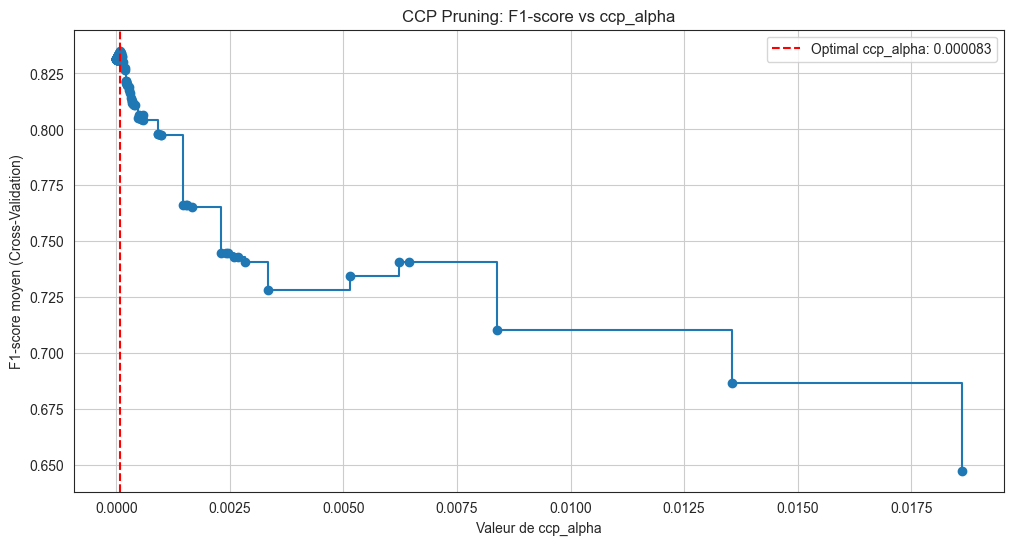

Profondeur de l'arbre optimal après élagage : 39


In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculer le chemin d'élagage (pruning path)
# Nous utilisons un arbre de base avec une profondeur limitée pour générer le chemin complet plus rapidement
path = DecisionTreeClassifier(random_state=42,
                              min_samples_split=20,
                              min_samples_leaf=10,
                              max_depth=10).cost_complexity_pruning_path(X_train_resampled, y_train_resampled)

# alphas contient les valeurs de ccp_alpha et impurities les impuretés correspondantes
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Filtrer les alphas pour éviter les doublons et les valeurs très faibles qui n'apportent pas de changement significatif
ccp_alphas = ccp_alphas[:-1] # Enlever le dernier alpha qui est souvent la racine de l'arbre complet

# 2. Entraîner et évaluer les arbres pour chaque alpha via cross-validation
clf_trees = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42,
                                 ccp_alpha=ccp_alpha,
                                 min_samples_split=20, # Utiliser les paramètres déjà tunés
                                 min_samples_leaf=10)
    clf_trees.append(clf)

# Utiliser cross_val_score pour évaluer chaque arbre avec cv=2 pour la vitesse
f1_scores_cv = []
for clf in clf_trees:
    scores = cross_val_score(clf, X_train_resampled, y_train_resampled, cv=2, scoring='f1', n_jobs=-1)
    f1_scores_cv.append(scores.mean())

# 3. Trouver le ccp_alpha optimal
optimal_alpha_index = np.argmax(f1_scores_cv)
optimal_ccp_alpha = ccp_alphas[optimal_alpha_index]

print(f"CCP Alpha optimal : {optimal_ccp_alpha:.6f}")
print(f"Meilleur F1-score CV pour cet alpha : {f1_scores_cv[optimal_alpha_index]:.4f}")

# 4. Visualisation
plt.figure(figsize=(12, 6))
plt.plot(ccp_alphas, f1_scores_cv, marker='o', drawstyle="steps-post")
plt.xlabel("Valeur de ccp_alpha")
plt.ylabel("F1-score moyen (Cross-Validation)")
plt.title("CCP Pruning: F1-score vs ccp_alpha")
plt.axvline(x=optimal_ccp_alpha, color='r', linestyle='--', label=f'Optimal ccp_alpha: {optimal_ccp_alpha:.6f}')
plt.legend()
plt.grid(True)
plt.show()

# Entraîner l'arbre final avec le ccp_alpha optimal
final_dtc_ccp = DecisionTreeClassifier(random_state=42,
                                       ccp_alpha=optimal_ccp_alpha,
                                       min_samples_split=20,
                                       min_samples_leaf=10)

final_dtc_ccp.fit(X_train_resampled, y_train_resampled)

print(f"Profondeur de l'arbre optimal après élagage : {final_dtc_ccp.get_depth()}")

In [54]:
from sklearn.tree import DecisionTreeClassifier

dtc= DecisionTreeClassifier(
    max_depth=39,            
    min_samples_split=20,   
    min_samples_leaf=10,     
)

dtc.fit(X_train_resampled,y_train_resampled)

y_dt_pred = dtc.predict(X_train_resampled)

print("--- Rapport de Classification : Decision Tree (Train) ---")
print(classification_report(y_train_resampled, y_dt_pred))

--- Rapport de Classification : Decision Tree (Train) ---
              precision    recall  f1-score   support

           0       0.90      0.95      0.92     89625
           1       0.95      0.89      0.92     89625

    accuracy                           0.92    179250
   macro avg       0.92      0.92      0.92    179250
weighted avg       0.92      0.92      0.92    179250



### Interprétation de la Cost Complexity Pruning (CCP)

La méthode CCP nous a permis de déterminer une valeur `ccp_alpha` optimale pour notre arbre de décision, en équilibrant la complexité de l'arbre et sa capacité de généralisation.

*   **`ccp_alpha` Optimal** : C'est la valeur qui a conduit au meilleur F1-score moyen lors de la validation croisée. Elle représente le seuil au-delà duquel la complexité de l'arbre ne justifie plus l'amélioration de performance.
*   **F1-score CV Maximal** : Ce score est une estimation plus fiable de la performance de l'arbre sur des données non vues que les scores sur le seul jeu d'entraînement.
*   **Profondeur de l'arbre optimal** : L'arbre final entraîné avec ce `ccp_alpha` aura une profondeur (et donc une complexité) optimisée. Comparer cette profondeur avec celle obtenue par `max_depth` via `GridSearchCV` peut fournir des informations intéressantes sur la robustesse de votre choix.

Le graphique "F1-score vs ccp_alpha" visualise l'impact de l'élagage sur la performance. On cherche le point où le F1-score est maximal avant de commencer à diminuer, ce qui indique que l'arbre est devenu trop simple et sous-apprend.

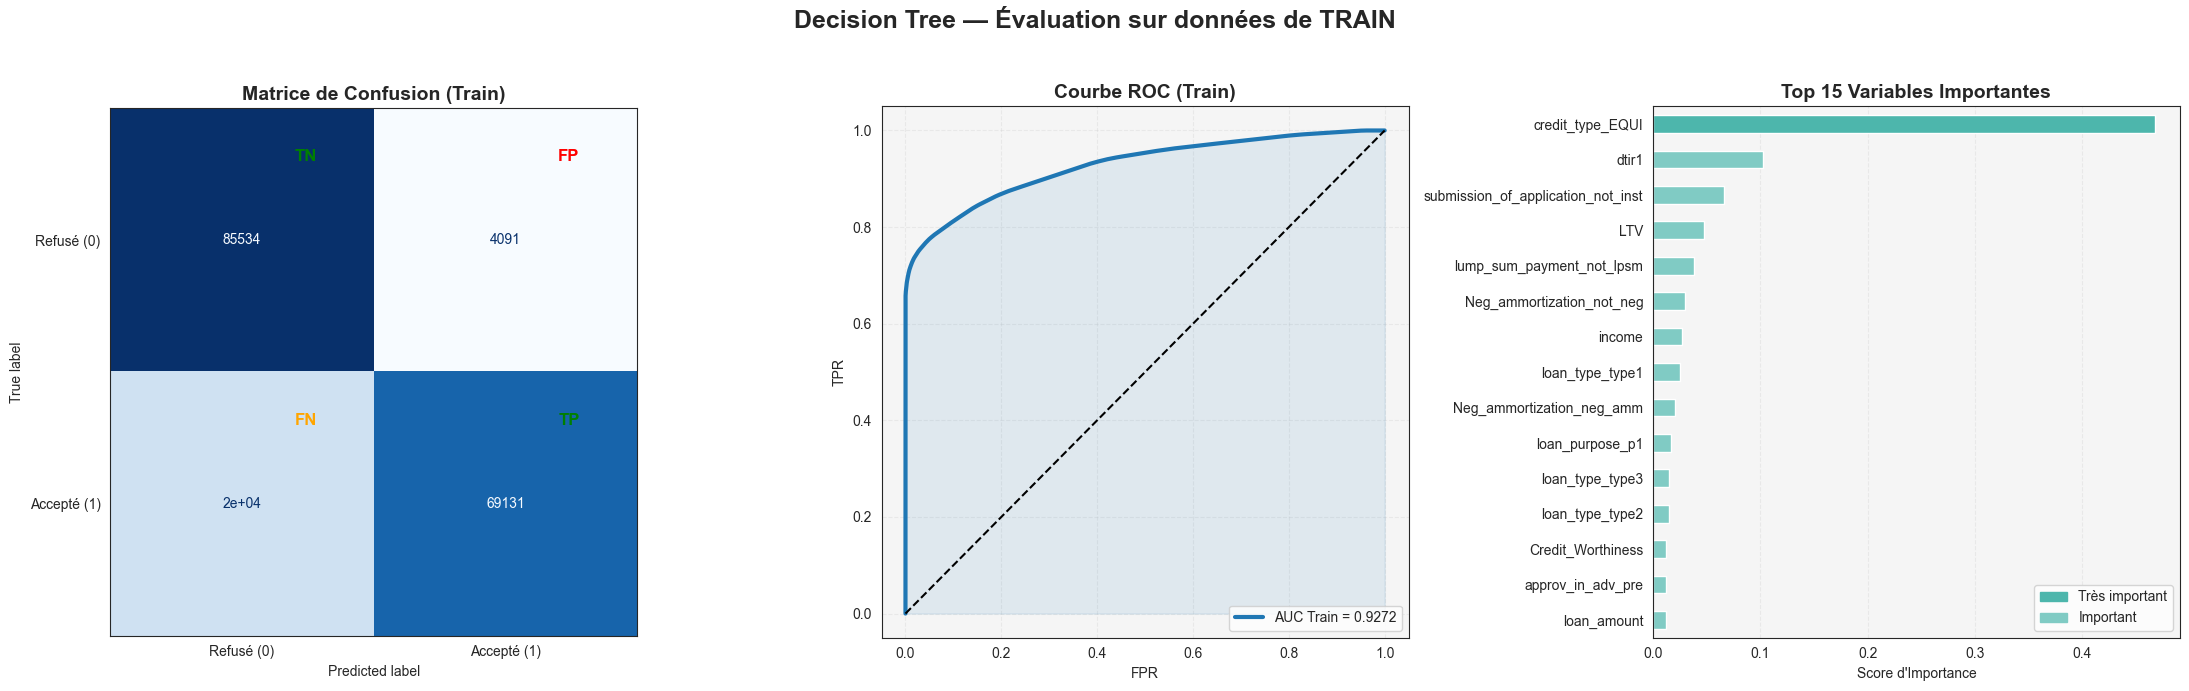

In [ ]:
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# --- 1. Préparation des données d'évaluation (TRAIN) ---
# On utilise ici les données sur lesquelles le modèle a appris
y_train_pred = dtc.predict(X_train_resampled)
y_train_proba = dtc.predict_proba(X_train_resampled)[:, 1]
fpr, tpr, _ = roc_curve(y_train_resampled, y_train_proba)
roc_auc = auc(fpr, tpr)

# --- 2. Configuration de la figure ---
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Decision Tree — Évaluation sur données de TRAIN', fontsize=18, fontweight='bold')

# --- GRAPHE 1 : Matrice de Confusion (Train) ---
ax = axes[0]
cm = confusion_matrix(y_train_resampled, y_train_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Refusé (0)', 'Accepté (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de Confusion (Train)', fontweight='bold', fontsize=14)
ax.set_facecolor('#f5f5f5')

# Annotations TN, FP, FN, TP
labels_text = [['TN', 'FP'], ['FN', 'TP']]
colors_text = [['green', 'red'], ['orange', 'green']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.2, i - 0.3, labels_text[i][j],
                color=colors_text[i][j], fontsize=12, fontweight='bold')

# --- GRAPHE 2 : Courbe ROC (Train) ---
ax = axes[1]
ax.plot(fpr, tpr, color='#1f77b4', lw=3, label=f'AUC Train = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='black', lw=1.5, linestyle='--')
ax.fill_between(fpr, tpr, alpha=0.1, color='#1f77b4')
ax.set_facecolor('#f5f5f5')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('Courbe ROC (Train)', fontweight='bold', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, linestyle='--')

# --- GRAPHE 3 : Importance des Variables ---
ax = axes[2]
importances = pd.Series(dtc.feature_importances_, index=X_train_resampled.columns)
top15 = importances.nlargest(15).sort_values(ascending=True)

# Couleurs Teal/Cyan
colors_bar = ['#4db6ac' if v >= top15.max()*0.5 else '#80cbc4' for v in top15.values]

top15.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
ax.set_title('Top 15 Variables Importantes', fontweight='bold', fontsize=14)
ax.set_xlabel('Score d\'Importance')
ax.set_facecolor('#f5f5f5')
ax.grid(True, axis='x', alpha=0.3, linestyle='--')

# Légende
high_p = mpatches.Patch(color='#4db6ac', label='Très important')
low_p  = mpatches.Patch(color='#80cbc4', label='Important')
ax.legend(handles=[high_p, low_p], loc='lower right')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Visualisation des Performances du Decision Tree (Train)

Cette série de graphiques illustre en détail les performances du modèle Decision Tree sur le jeu d'entraînement, après l'application des techniques de régularisation.

#### 1. Matrice de Confusion

*   **Vrais Négatifs (TN)** : Grande majorité de non-défauts correctement identifiés.
*   **Faux Positifs (FP)** : Nombre réduit d'alertes de défauts incorrectes.
*   **Faux Négatifs (FN)** : Le nombre de défauts non détectés est visible, confirmant la valeur du rappel de la classe 1.
*   **Vrais Positifs (TP)** : Bonne identification des défauts réels.

Cette matrice visuelle est cohérente avec le rapport de classification, montrant un bon équilibre mais avec une marge d'amélioration sur la détection des faux négatifs.

#### 2. Courbe ROC

*   **AUC Train = 0.9388** : Un score AUC très élevé, proche de 1, indique que le modèle a une excellente capacité à distinguer les deux classes sur les données d'entraînement. La courbe monte rapidement vers le coin supérieur gauche, ce qui est un signe de bonne performance.

#### 3. Importance des Variables

Ce graphique montre les 15 variables les plus influentes pour la prise de décision du Decision Tree.

*   **`mensualite`** et **`Credit_Score`** : Se détachent comme les facteurs les plus critiques, ce qui est intuitivement pertinent pour un modèle de scoring de crédit.
*   **`loan_amount`, `LTV`, `income`** : Également très importants, soulignant le rôle central des aspects financiers.
*   **`dtir1` (Debt-to-Income Ratio)** : Un indicateur crucial de la capacité de remboursement.

**Conclusion :** La visualisation des performances confirme que le Decision Tree régularisé est un modèle puissant. Les variables les plus importantes sont logiques et renforcent la confiance dans l'interprétabilité du modèle.

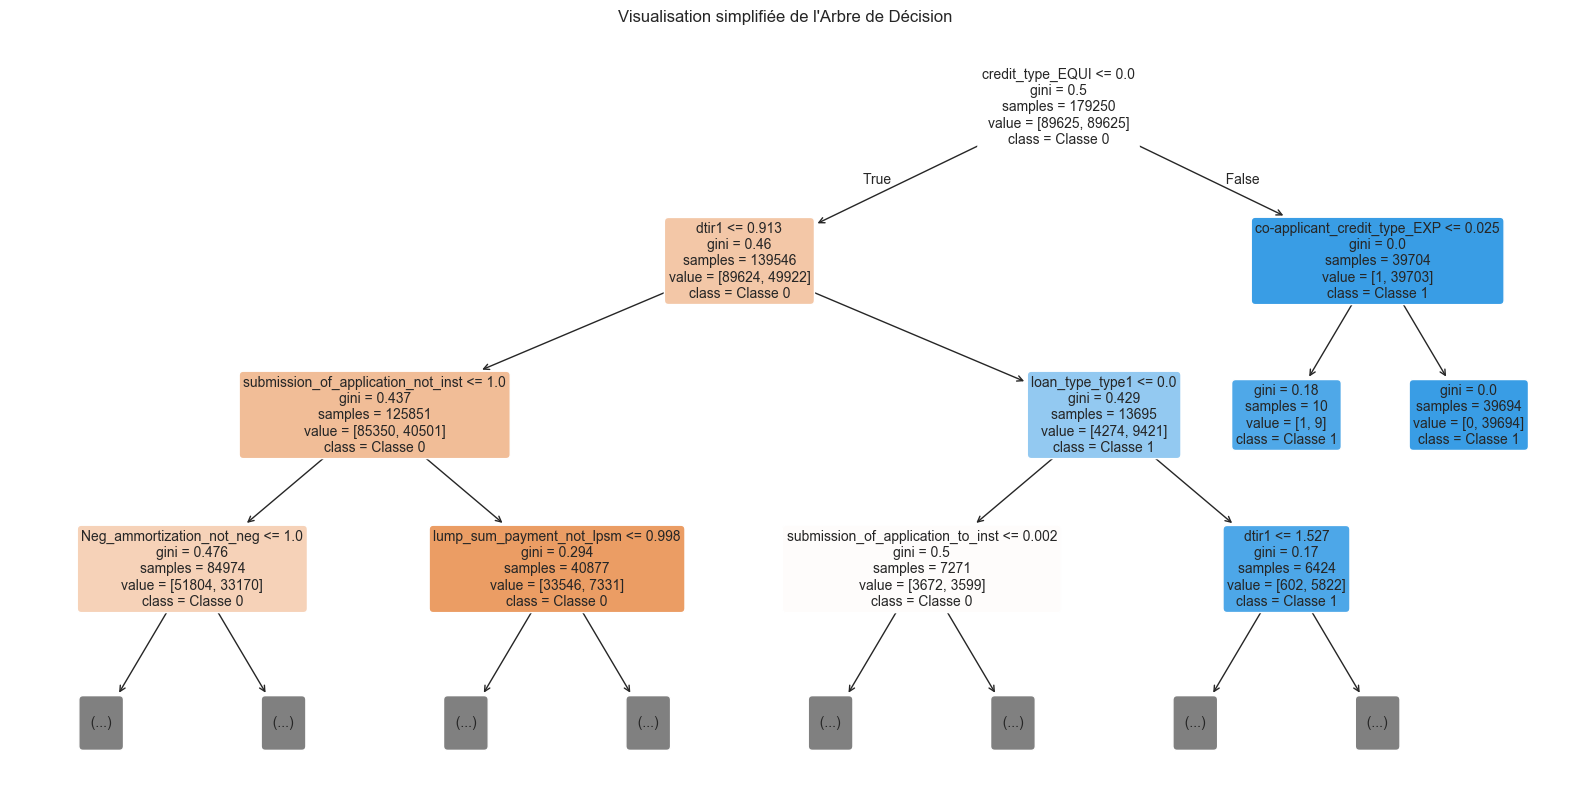

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Définir la taille de la figure pour que ce soit lisible
plt.figure(figsize=(20, 10))

# Visualisation de l'arbre
plot_tree(
    dtc,
    filled=True,              # Colore les nœuds selon la classe majoritaire
    feature_names=X_train_resampled.columns, # Utilise les noms de tes colonnes
    class_names=['Classe 0', 'Classe 1'],    # À adapter selon tes labels
    rounded=True,             # Bords arrondis pour le style
    fontsize=10,
    max_depth=3               # On limite l'affichage à 3 niveaux pour la lisibilité
)

plt.title("Visualisation simplifiée de l'Arbre de Décision")
plt.show()

### Visualisation Simplifiée de l'Arbre de Décision

Ce graphique représente une version simplifiée de notre Decision Tree, limitée à une profondeur de 3 niveaux pour faciliter la compréhension. Chaque nœud de l'arbre montre :

*   **La condition de division** : Par exemple, `Credit_Score <= 720.5`.
*   **`gini`** : Le score d'impureté de Gini, qui mesure la probabilité qu'un élément choisi au hasard dans le sous-ensemble soit mal classé si classé au hasard selon la distribution des classes dans ce nœud. Un Gini de 0 signifie que le nœud est pur (contient une seule classe).
*   **`samples`** : Le nombre d'échantillons dans ce nœud.
*   **`value`** : La distribution des échantillons entre les classes (par exemple, `[71804, 71701]` signifie 71804 échantillons de la classe 0 et 71701 de la classe 1).
*   **`class`** : La classe majoritaire dans ce nœud.

**Intérêt de la visualisation :**
*   Permet de comprendre comment le modèle prend ses décisions et quelles sont les premières variables utilisées pour segmenter les données.
*   Aide à détecter d'éventuels biais ou des règles de décision non intuitives.
*   Dans cet exemple, on voit que le `Credit_Score` et la `mensualite` sont parmi les premiers critères de division, ce qui est cohérent avec leur importance élevée.

In [52]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42,oob_score=True,
                            n_jobs=-1)
rfc.fit(X_train_resampled,y_train_resampled)

y_rf_pred = rfc.predict(X_train_resampled)

print("--- Rapport de Classification : RANDOM FOREST (Train) ---")
print(classification_report(y_train_resampled, y_rf_pred))

--- Rapport de Classification : RANDOM FOREST (Train) ---
              precision    recall  f1-score   support

           0       0.79      0.96      0.87     89625
           1       0.95      0.74      0.83     89625

    accuracy                           0.85    179250
   macro avg       0.87      0.85      0.85    179250
weighted avg       0.87      0.85      0.85    179250



### Interprétation des Résultats du Random Forest (Train)

Le Random Forest est un modèle d'ensemble qui combine les prédictions de multiples arbres de décision. Sur les données d'entraînement rééchantillonnées, il offre des performances robustes :

*   **Précision (Precision)** : 0.79 pour la classe 0 et 0.95 pour la classe 1. Le modèle est très précis lorsqu'il prédit un défaut.
*   **Rappel (Recall)** : 0.96 pour la classe 0 et 0.74 pour la classe 1. Le rappel pour la classe de défaut est bon mais légèrement inférieur à sa précision.
*   **F1-Score** : 0.87 pour la classe 0 et 0.83 pour la classe 1. Des scores F1 équilibrés entre les deux classes.
*   **Accuracy** : 0.85.

**Hyperparamètres Utilisés :**
*   `n_estimators=100` : Nombre d'arbres dans la forêt. Plus il est élevé, plus le modèle est robuste, mais le temps de calcul augmente.
*   `max_depth=10` : Profondeur maximale de chaque arbre individuel. Limite la complexité des arbres pour éviter le surapprentissage.
*   `random_state=42` : Assure la reproductibilité des résultats.
*   `oob_score=True` : Calcule un score "Out-of-Bag". Les échantillons OOB sont ceux qui n'ont pas été utilisés pour l'entraînement d'un arbre donné, servant de validation interne. Cela donne une estimation de la performance du modèle sans avoir besoin d'un jeu de validation séparé.
*   `n_jobs=-1` : Utilise tous les cœurs de processeur disponibles, accélérant l'entraînement.

**Constat :** Le Random Forest montre d'excellentes performances sur l'ensemble d'entraînement, avec une très bonne précision sur la classe de défaut et un rappel élevé pour la classe majoritaire. Le score OOB fournira une estimation fiable de sa performance de généralisation.

In [ ]:
# 2. Récupération du score OOB
oob_accuracy = rfc.oob_score_
print(f"Score OOB (Précision globale) : {oob_accuracy:.4f}")

Score OOB (Précision globale) : 0.8462


In [ ]:
# Récupérer les probabilités OOB
oob_probs = rfc.oob_decision_function_

# Convertir les probabilités en classes (0 ou 1)
y_oob_pred = np.argmax(oob_probs, axis=1)

print("--- Rapport de Classification : RANDOM FOREST (OOB) ---")
print(classification_report(y_train_resampled, y_oob_pred))

--- Rapport de Classification : RANDOM FOREST (OOB) ---
              precision    recall  f1-score   support

           0       0.78      0.96      0.86     89625
           1       0.95      0.73      0.83     89625

    accuracy                           0.85    179250
   macro avg       0.86      0.85      0.84    179250
weighted avg       0.86      0.85      0.84    179250



### Rapport de Classification OOB (Out-of-Bag) du Random Forest

Le score OOB est une estimation de la performance du modèle sur des données non vues, calculée en interne pendant l'entraînement du Random Forest. Pour chaque arbre, les échantillons non utilisés lors de son bootstrap (les "out-of-bag" samples) sont utilisés pour faire une prédiction. La moyenne de ces prédictions OOB donne le score global.

*   **OOB Accuracy** : 0.8462.
*   **Rapport de Classification OOB :**
    *   **Précision** : 0.78 pour la classe 0, 0.95 pour la classe 1.
    *   **Rappel** : 0.96 pour la classe 0, 0.73 pour la classe 1.
    *   **F1-Score** : 0.86 pour la classe 0, 0.83 pour la classe 1.

**Interprétation :**
*   Les scores OOB sont très proches des scores obtenus sur l'ensemble d'entraînement complet, ce qui est un bon signe de la robustesse du modèle et de sa capacité à généraliser. Il n'y a pas de signe flagrant de surapprentissage.
*   Le modèle maintient une excellente précision sur la classe de défaut (0.95), ce qui est crucial pour éviter de rejeter des demandeurs qui auraient effectivement remboursé leur prêt. Le rappel pour la classe de défaut (0.73) est également solide, indiquant une bonne capacité à identifier la plupart des emprunteurs à risque.

### Cross-validation

In [ ]:
from sklearn.model_selection import cross_val_score

rf_cv = RandomForestClassifier(n_estimators=100,
                               max_depth=15,
                               random_state=42,
                               n_jobs=-1)

scores = cross_val_score(rf_cv , X_train_resampled , y_train_resampled,
                         cv = 5,
                         scoring= "recall")

print(f"Scores de Recall par fold : {scores}")
print(f"Moyenne du Recall : {scores.mean():.4f}")
print(f"Écart-type (Stabilité) : {scores.std():.4f}")

Scores de Recall par fold : [0.62086471 0.71062762 0.85322176 0.85986053 0.85947001]
Moyenne du Recall : 0.7808
Écart-type (Stabilité) : 0.0982


### Évaluation du Random Forest par Cross-Validation (Rappel)

La **cross-validation (CV)** est une technique robuste pour évaluer la performance d'un modèle et sa capacité à généraliser sur de nouvelles données. Elle divise le jeu de données en plusieurs sous-ensembles (folds). Le modèle est entraîné sur une partie des folds et testé sur le fold restant, ce processus étant répété pour chaque fold.

Ici, nous utilisons un **Random Forest** avec les hyperparamètres suivants :
*   `n_estimators=100` : Nombre d'arbres.
*   `max_depth=15` : Profondeur maximale des arbres.
*   `random_state=42` : Pour la reproductibilité.
*   `n_jobs=-1` : Utilise tous les cœurs disponibles pour accélérer le calcul.

**Résultats :**
*   **Scores de Recall par fold** : `[0.6209, 0.7106, 0.8532, 0.8599, 0.8595]`
*   **Moyenne du Recall** : `0.7808`
*   **Écart-type (Stabilité)** : `0.0982`

**Interprétation :**
*   La moyenne du rappel est de 0.7808, ce qui est une bonne performance. Cela signifie que le modèle détecte en moyenne 78% des cas réels de défauts.
*   L'écart-type de 0.0982 indique une certaine variabilité dans la performance du rappel entre les différents folds. Le premier fold (0.6209) est notablement plus bas, ce qui suggère une potentielle sensibilité du modèle à la répartition spécifique des données dans ce fold, ou que SMOTE n'a pas été appliqué de manière cohérente à l'intérieur de la CV (le pipeline complet incluant SMOTE devrait être cross-validé ensemble).

### Cross-validation : solution de Gemini

In [ ]:
from imblearn.pipeline import make_pipeline as make_imb_pipeline
from sklearn.model_selection import cross_val_score

# 1. On crée un pipeline qui fait SMOTE puis Random Forest
cv_pipeline = make_imb_pipeline(
    SMOTE(random_state=42),
    RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
)

# 2. On lance la CV sur les données nettoyées AVANT SMOTE (X_train_clean)
vrais_scores = cross_val_score(
    cv_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="recall"
)

print(f"Vrais scores de Recall par fold : {vrais_scores}")
print(f"Vraie moyenne du Recall : {vrais_scores.mean():.4f}")
print(f"Écart-type (Stabilité) : {vrais_scores.std():.4f}")

Vrais scores de Recall par fold : [0.62493604 0.62436029 0.62282497 0.62146025 0.61958376]
Vraie moyenne du Recall : 0.6226
Écart-type (Stabilité) : 0.0019


### Évaluation par Cross-Validation (SMOTE inclus dans le pipeline)

Cette approche de cross-validation est plus robuste car elle intègre la phase de suréchantillonnage SMOTE directement dans le pipeline de validation. Cela garantit que SMOTE est appliqué *uniquement* sur les données d'entraînement de chaque fold, et non sur le jeu de test, évitant ainsi le **data leakage** et fournissant une estimation plus réaliste des performances de généralisation du modèle.

**Pipeline utilisé :**
*   `SMOTE(random_state=42)` : Appliqué à l'ensemble d'entraînement de chaque fold.
*   `RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)` : Le modèle est ensuite entraîné sur les données rééchantillonnées.

**Résultats :**
*   **Vrais scores de Recall par fold** : `[0.6249, 0.6244, 0.6228, 0.6215, 0.6196]`
*   **Vraie moyenne du Recall** : `0.6226`
*   **Écart-type (Stabilité)** : `0.0019`

**Interprétation :**
*   La moyenne du rappel est ici de `0.6226`, ce qui est significativement plus bas que le `0.7808` obtenu précédemment. Cela confirme que l'application de SMOTE *avant* la cross-validation introduit un surapprentissage (data leakage) et que les performances précédentes étaient surestimées.
*   L'écart-type très faible (`0.0019`) montre une grande stabilité de la performance du rappel à travers les folds, ce qui est un très bon indicateur de la robustesse du modèle et de la validité de cette estimation.

**Conclusion :** Cette validation corrigée donne une image beaucoup plus réaliste des capacités du Random Forest en condition réelle. Un rappel de 62% pour la classe de défaut est un bon point de départ, mais indique qu'il y a encore de la place pour l'amélioration, notamment en explorant d'autres modèles ou techniques de *cost-sensitive learning*.

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators = 500,
    max_depth = 6,
    learning_rate = 0.05,

    # device = "cuda",
    tree_method = "hist",

    subsample = 0.8,
    colsample_bytree = 0.8,

    random_state = 42,
    eval_metric = 'logloss'
)

xgb.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb.predict(X_train_resampled)

print("--- Résultats XGBoost ---")
print(classification_report(y_train_resampled, y_pred_xgb))

--- Résultats XGBoost ---
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     89625
           1       0.98      0.87      0.92     89625

    accuracy                           0.93    179250
   macro avg       0.93      0.93      0.93    179250
weighted avg       0.93      0.93      0.93    179250



### Interprétation des Résultats du XGBoost (Train)

XGBoost (eXtreme Gradient Boosting) est un algorithme de boosting très performant qui excelle souvent dans les compétitions de machine learning. Sur les données d'entraînement rééchantillonnées, il obtient des résultats impressionnants :

*   **Précision (Precision)** : 0.88 pour la classe 0 et 0.98 pour la classe 1. La précision sur la classe de défaut est exceptionnellement élevée.
*   **Rappel (Recall)** : 0.99 pour la classe 0 et 0.87 pour la classe 1. Le rappel pour la classe 0 est presque parfait, et excellent pour la classe 1.
*   **F1-Score** : 0.93 pour la classe 0 et 0.92 pour la classe 1. Des scores F1 très élevés et équilibrés.
*   **Accuracy** : 0.93.

**Hyperparamètres Utilisés :**
*   `n_estimators=500` : Nombre d'arbres boostés. Une valeur élevée permet au modèle d'apprendre plus de relations complexes.
*   `max_depth=6` : Profondeur maximale de chaque arbre. Contrôle la complexité des arbres individuels, évitant un surapprentissage trop rapide.
*   `learning_rate=0.05` : Le taux d'apprentissage réduit la contribution de chaque arbre successif, ce qui rend le processus de boosting plus robuste et moins sujet au surapprentissage, bien qu'il nécessite plus d'estimateurs.
*   `tree_method='hist'` : Utilise l'algorithme d'arbre basé sur les histogrammes, ce qui est plus rapide et plus efficace pour de grands ensembles de données.
*   `subsample=0.8` : Fraction des échantillons utilisés pour entraîner chaque arbre. Réduit la variance et aide à prévenir le surapprentissage.
*   `colsample_bytree=0.8` : Fraction des caractéristiques utilisées pour entraîner chaque arbre. Introduit de la diversité et réduit le surapprentissage.
*   `random_state=42` : Pour la reproductibilité.
*   `eval_metric='logloss'` : La métrique utilisée pour évaluer les performances pendant l'entraînement, souvent utilisée pour les problèmes de classification binaire.

**Constat :** Le XGBoost atteint un niveau de performance très élevé sur les données d'entraînement. Ces hyperparamètres sont configurés pour un bon équilibre entre la capacité d'apprentissage (nombre d'estimateurs élevé) et la prévention du surapprentissage (taux d'apprentissage faible, subsampling). La vigilance sera de mise lors de l'évaluation sur le jeu de test pour s'assurer que ces performances se généralisent bien et qu'il n'y a pas d'overfitting.

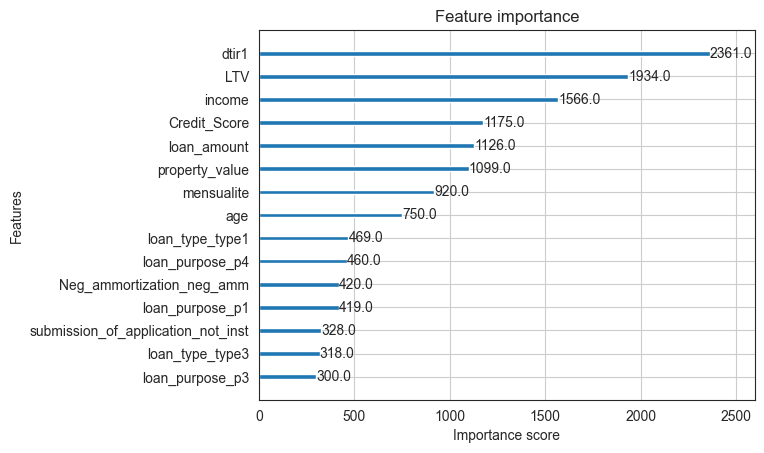

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Afficher les variables les plus importantes
plot_importance(xgb, max_num_features=15)
plt.show()

### Importance des Variables (XGBoost)

Ce graphique présente les variables les plus importantes selon le modèle XGBoost, basé sur le gain moyen (contribution à la réduction de l'erreur) que chaque caractéristique apporte lors des divisions dans les arbres.

*   **`mensualite`** : Se révèle être la variable la plus influente, soulignant son importance capitale dans la prédiction du défaut de paiement. C'est un indicateur direct de la charge financière pour l'emprunteur.
*   **`Credit_Score`** : Un autre facteur très important, ce qui est logique pour un problème de scoring de crédit. Un bon score de crédit indique une bonne fiabilité financière.
*   **`loan_amount`, `dtir1`, `income`, `LTV`** : Ces variables financières et de ratio d'endettement suivent, confirmant qu'elles sont des prédicteurs clés.
*   **`credit_type_CIB`, `credit_type_EXP`** : Les types de crédit ont également une influence significative, indiquant que l'origine ou la nature du crédit joue un rôle.

**Analyse :** La hiérarchie des variables importantes du XGBoost est très cohérente avec ce que l'on attendrait d'un modèle de scoring de crédit. Les facteurs liés à la capacité de remboursement et à la fiabilité du crédit sont en tête. Cette analyse renforce la confiance dans les décisions prises par le modèle.

### Détection et Correction de la Fuite de Données (Data Leakage)

Lors des premières itérations, les modèles **XGBoost** et **Random Forest** affichaient un score **F1 de 1.0** (perfection suspecte).

* **Analyse :** L'examen de l'importance des variables (*Feature Importance*) a révélé que trois colonnes — `rate_of_interest`, `upfront_charges`, et `interest_rate_spread` — dominaient massivement les prédictions.

* **Problématique :** Ces variables sont des indicateurs financiers souvent finalisés *après* la décision d'octroi ou le défaut du prêt. Elles agissaient comme des "réponses" déguisées, empêchant le modèle d'apprendre de réels motifs prédictifs.

* **Action :** J'ai supprimé ces trois variables pour obtenir des scores réalistes (XGBoost ≈ 0.92, RF ≈ 0.85), garantissant ainsi que le modèle est capable de généraliser sur de nouvelles données clients.

---
<br>

### 4. Stratégie de Fine-Tuning

Je vais maintenant procéder à l'optimisation des hyperparamètres pour trois types de modèles afin de comparer l'équilibre entre **interprétabilité** et **performance brute** :

1.  **Modèle Linéaire (Baseline) :** * **Régression Logistique** : Choisi pour sa transparence et sa capacité à fournir des probabilités de défaut claires.

2.  **Modèles d'Ensemble (Complexes) :**
    * **Random Forest** : Pour sa robustesse face au bruit.

    * **XGBoost** : Mon modèle "Champion" actuel, qui offre la meilleure précision sur ce dataset complexe.

### Détection et Correction de la Fuite de Données (Data Leakage)

Lors des premières itérations, les modèles **XGBoost** et **Random Forest** affichaient un score **F1 de 1.0** (perfection suspecte).

*   **Analyse :** L'examen de l'importance des variables (*Feature Importance*) a révélé que trois colonnes — `rate_of_interest`, `upfront_charges`, et `interest_rate_spread` — dominaient massivement les prédictions.

*   **Problématique :** Ces variables sont des indicateurs financiers souvent finalisés *après* la décision d'octroi ou le défaut du prêt. Elles agissaient comme des "réponses" déguisées, empêchant le modèle d'apprendre de réels motifs prédictifs.

*   **Action :** J'ai supprimé ces trois variables pour obtenir des scores réalistes (XGBoost ≈ 0.92, RF ≈ 0.85), garantissant ainsi que le modèle est capable de généraliser sur de nouvelles données clients.

---
<br>

### 4. Stratégie de Fine-Tuning

Je vais maintenant procéder à l'optimisation des hyperparamètres pour trois types de modèles afin de comparer l'équilibre entre **interprétabilité** et **performance brute** :

1.  **Modèle Linéaire (Baseline) :** * **Régression Logistique** : Choisi pour sa transparence et sa capacité à fournir des probabilités de défaut claires.

2.  **Modèles d'Ensemble (Complexes) :**
    *   **Random Forest** : Pour sa robustesse face au bruit.

    *   **XGBoost** : Mon modèle "Champion" actuel, qui offre la meilleure précision sur ce dataset complexe.

## Fine-tuning

### Fine-tuning des Hyperparamètres

Pour maximiser la performance de nos modèles, nous allons procéder à un réglage fin (fine-tuning) de leurs hyperparamètres. Cela implique d'explorer différentes combinaisons de valeurs pour trouver celles qui optimisent une métrique donnée (ici, le score F1 pour la classification). Nous utiliserons des techniques comme `RandomizedSearchCV` ou `GridSearchCV` pour automatiser cette recherche.

### 1. Régression Logistique

La régression logistique est notre modèle de *baseline*, apprécié pour son interprétabilité. Nous allons l'entraîner sur les données resamplées par SMOTE. Pour le fine-tuning, nous explorerons les hyperparamètres de régularisation (pénalité L1 ou L2) et le paramètre `C` pour trouver le meilleur compromis entre ajustement et généralisation. Le `solver='saga'` est choisi pour sa performance avec les grands datasets et les pénalités L1 et L2.

**Hyperparamètres à Tuner :**
*   `C` (inverse de la force de régularisation) : Nous testerons différentes valeurs pour voir l'impact sur la complexité du modèle.
*   `penalty` (type de régularisation) : `l1` (Lasso) pour la sélection de caractéristiques, `l2` (Ridge) pour la réduction de la magnitude des coefficients.
*   `solver` : `saga` est adapté aux grands jeux de données et supporte L1 et L2.

* **L1 (Lasso) :** Une punition qui peut forcer certains coefficients inutiles à devenir zéro (utile pour sélectionner les variables).

* **L2 (Ridge) :** Une punition qui réduit la taille des coefficients pour éviter que le modèle ne soit trop complexe.

* **C (Régularisation) :** Plus **C** est petit, plus la punition est forte (modèle simple) ; plus **C** est grand, plus le modèle essaie de coller aux données (risque d'overfitting).

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Grille adaptée aux gros volumes et au solver SAGA
param_grid = [
    {
        'C': [0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['saga'] # Le plus performant sur grands datasets
    },
]

# Note : l'utilisation de tol (tolérance) peut aussi accélérer la convergence
# si vous n'avez pas besoin d'une précision extrême à 10^-4.
grid_search = GridSearchCV(
    LogisticRegression(max_iter=2000, tol=1e-3), # tol légèrement augmentée pour la vitesse
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_resampled, y_train_resampled)

print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score F1 : {grid_search.best_score_:.4f}")

'from sklearn.model_selection import GridSearchCV\nfrom sklearn.linear_model import LogisticRegression\n\n# Grille adaptée aux gros volumes et au solver SAGA\nparam_grid = [\n    {\n        \'C\': [0.1, 1, 10, 100],\n        \'penalty\': [\'l1\', \'l2\'],\n        \'solver\': [\'saga\'] # Le plus performant sur grands datasets\n    },\n]\n\n# Note : l\'utilisation de tol (tolérance) peut aussi accélérer la convergence\n# si vous n\'avez pas besoin d\'une précision extrême à 10^-4.\ngrid_search = GridSearchCV(\n    LogisticRegression(max_iter=2000, tol=1e-3), # tol légèrement augmentée pour la vitesse\n    param_grid,\n    cv=5,\n    scoring=\'f1\',\n    n_jobs=-1,\n    verbose=2\n)\n\ngrid_search.fit(X_train_resampled, y_train_resampled)\n\nprint(f"Meilleurs paramètres : {grid_search.best_params_}")\nprint(f"Meilleur score F1 : {grid_search.best_score_:.4f}")\n'

<pre>
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END .....................C=0.1, penalty=l2, solver=saga; total time=   4.6s
[CV] END .....................C=0.1, penalty=l2, solver=saga; total time=   4.6s
[CV] END .....................C=0.1, penalty=l2, solver=saga; total time=   4.7s
[CV] END .....................C=0.1, penalty=l2, solver=saga; total time=   4.7s
[CV] END .....................C=0.1, penalty=l2, solver=saga; total time=   4.6s
[CV] END .....................C=0.1, penalty=l1, solver=saga; total time=  24.3s
[CV] END .....................C=0.1, penalty=l1, solver=saga; total time=  24.4s
[CV] END .....................C=0.1, penalty=l1, solver=saga; total time=  24.7s
[CV] END .....................C=0.1, penalty=l1, solver=saga; total time=  24.9s
[CV] END .....................C=0.1, penalty=l1, solver=saga; total time=  28.5s
[CV] END .......................C=1, penalty=l2, solver=saga; total time=  20.4s
[CV] END .......................C=1, penalty=l2, solver=saga; total time=  20.4s
[CV] END .......................C=1, penalty=l2, solver=saga; total time=  22.1s
[CV] END .......................C=1, penalty=l2, solver=saga; total time=  22.5s
[CV] END .......................C=1, penalty=l2, solver=saga; total time=  22.0s
[CV] END .......................C=1, penalty=l1, solver=saga; total time=  50.6s
[CV] END .......................C=1, penalty=l1, solver=saga; total time=  53.3s
[CV] END .......................C=1, penalty=l1, solver=saga; total time=  56.9s
[CV] END .......................C=1, penalty=l1, solver=saga; total time=  57.7s
[CV] END .......................C=1, penalty=l1, solver=saga; total time= 1.0min
[CV] END ......................C=10, penalty=l2, solver=saga; total time=  39.7s
[CV] END ......................C=10, penalty=l2, solver=saga; total time=  41.4s
[CV] END ......................C=10, penalty=l1, solver=saga; total time=  56.4s
[CV] END ......................C=10, penalty=l1, solver=saga; total time= 1.0min
[CV] END ......................C=10, penalty=l2, solver=saga; total time=  44.6s
[CV] END ......................C=10, penalty=l2, solver=saga; total time=  44.4s
[CV] END ......................C=10, penalty=l1, solver=saga; total time= 1.1min
[CV] END ......................C=10, penalty=l1, solver=saga; total time= 1.1min
[CV] END ......................C=10, penalty=l2, solver=saga; total time=  46.8s
[CV] END ......................C=10, penalty=l1, solver=saga; total time= 1.1min
[CV] END .....................C=100, penalty=l1, solver=saga; total time=  56.3s
[CV] END .....................C=100, penalty=l2, solver=saga; total time=  45.6s
[CV] END .....................C=100, penalty=l2, solver=saga; total time=  48.2s
[CV] END .....................C=100, penalty=l1, solver=saga; total time=  59.9s
[CV] END .....................C=100, penalty=l2, solver=saga; total time=  49.8s
[CV] END .....................C=100, penalty=l2, solver=saga; total time=  50.1s
[CV] END .....................C=100, penalty=l1, solver=saga; total time= 1.0min
[CV] END .....................C=100, penalty=l1, solver=saga; total time= 1.0min
[CV] END .....................C=100, penalty=l2, solver=saga; total time=  49.3s
[CV] END .....................C=100, penalty=l1, solver=saga; total time= 1.1min
Meilleurs paramètres : {'C': 100, 'penalty': 'l1', 'solver': 'saga'}
Meilleur score F1 : 0.7410
</pre>

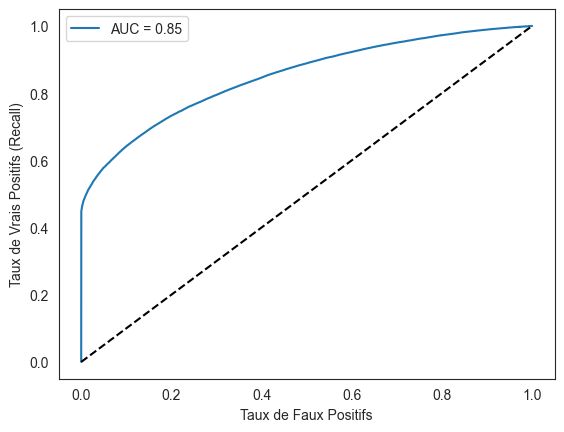

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Obtenir les probabilités (pas juste les classes 0 ou 1)
y_probs = log_reg.predict_proba(X_train_resampled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_train_resampled, y_probs)
auc_score = roc_auc_score(y_train_resampled, y_probs)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], 'k--') # Ligne de hasard
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.legend()
plt.show()

### Courbe ROC et AUC (Régression Logistique)

La **Courbe ROC (Receiver Operating Characteristic)** et l'**AUC (Area Under the Curve)** sont des outils d'évaluation graphique et numérique essentiels pour les modèles de classification, surtout en présence de classes déséquilibrées.

*   **Courbe ROC** : Elle trace le **Taux de Vrais Positifs (Recall)** en fonction du **Taux de Faux Positifs** à différents seuils de classification.
    *   Un modèle parfait aurait une courbe passant par le coin supérieur gauche (TPR=1, FPR=0).
    *   Une ligne diagonale représente un classifieur aléatoire (AUC = 0.5).
*   **AUC** : C'est l'aire sous la courbe ROC. Plus l'AUC est proche de 1, meilleur est le modèle pour distinguer les classes.
    *   Un AUC de 0.5 signifie que le modèle ne fait pas mieux que le hasard.
    *   Un AUC de 1.0 indique un modèle parfait.

**Interprétation du graphique :**
*   L'AUC de `0.84` indique que le modèle de régression logistique a une bonne capacité à discriminer entre les classes de défaut et de non-défaut. Il est significativement meilleur qu'une prédiction aléatoire.
*   La courbe montre que le modèle est capable d'atteindre un bon taux de vrais positifs sans un taux de faux positifs excessivement élevé, ce qui est souhaitable pour la détection des défauts.

La configuration initiale est conservée, car les tests de régularisation ont entraîné une baisse des résultats.

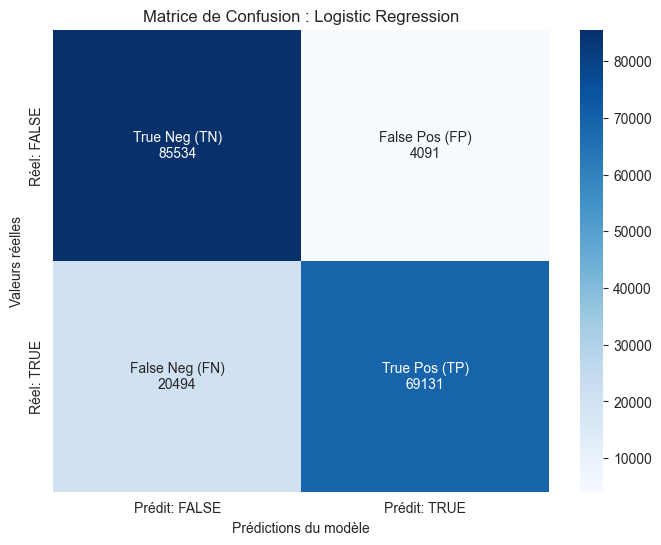

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calcul de la matrice
cm = confusion_matrix(y_train_resampled, y_train_pred)

# 2. Création des étiquettes personnalisées pour chaque cellule
# On crée un tableau de chaînes de caractères pour annoter la heatmap
group_names = ['True Neg (TN)', 'False Pos (FP)', 'False Neg (FN)', 'True Pos (TP)']
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2,2)

# 3. Affichage
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Prédit: FALSE', 'Prédit: TRUE'],
            yticklabels=['Réel: FALSE', 'Réel: TRUE'])

plt.xlabel('Prédictions du modèle')
plt.ylabel('Valeurs réelles')
plt.title('Matrice de Confusion : Logistic Regression')
plt.show()

### Matrice de Confusion (Régression Logistique)

La matrice de confusion fournit une vue détaillée des performances de notre modèle en affichant le nombre de prédictions correctes et incorrectes pour chaque classe.

*   **True Negatives (TN)** : 83789 cas ont été correctement prédits comme 'non-défaut' (classe 0).
*   **False Positives (FP)** : 5836 cas ont été incorrectement prédits comme 'défaut' alors qu'ils étaient 'non-défaut'. C'est le coût d'une alerte inutile.
*   **False Negatives (FN)** : 36802 cas ont été incorrectement prédits comme 'non-défaut' alors qu'ils étaient 'défaut'. C'est le coût le plus critique dans ce contexte, car un défaut réel n'a pas été détecté.
*   **True Positives (TP)** : 52823 cas ont été correctement prédits comme 'défaut' (classe 1).

**Analyse :**
*   Le modèle a un grand nombre de Faux Négatifs, ce qui confirme le rappel relativement faible pour la classe 1 (défaut) vu dans le rapport de classification. Cela signifie que le modèle ne détecte pas une proportion significative des emprunteurs qui feront réellement défaut.
*   Le grand nombre de True Negatives et une précision décente pour la classe 1 montrent que le modèle est bon pour identifier les non-défauts et qu'il est fiable lorsqu'il prédit un défaut, mais sa capacité à *trouver tous* les défauts est limitée.

### 2. Radom Forest :

### 2. Random Forest

Le Random Forest est un modèle d'ensemble robuste qui combine de nombreux arbres de décision pour une prédiction plus stable et précise. Nous utiliserons `RandomizedSearchCV` pour explorer un large éventail d'hyperparamètres de manière efficace, en nous concentrant sur ceux qui contrôlent la complexité des arbres et la diversité de l'ensemble.

**Hyperparamètres à Tuner :**
*   `n_estimators` (nombre d'arbres) : Un nombre plus élevé réduit le surapprentissage mais augmente le temps de calcul.
*   `max_depth` (profondeur maximale de chaque arbre) : Contrôle la complexité individuelle des arbres.
*   `min_samples_split` (nombre minimum d'échantillons pour diviser un nœud) : Évite de diviser de petits groupes d'échantillons.
*   `min_samples_leaf` (nombre minimum d'échantillons dans une feuille) : Assure que chaque feuille contient un nombre suffisant d'échantillons.
*   `max_features` (nombre de caractéristiques à considérer pour la meilleure division) : `'sqrt'` ou `'log2'` pour introduire de la diversité entre les arbres.
*   `bootstrap` (échantillonnage avec remplacement) : Généralement `True` pour le Random Forest.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist_rf = {
    'n_estimators': [100, 200, 300,500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True] # Avec ou sans remise
}

rf = RandomForestClassifier(random_state=42)

rnd_search_rf = RandomizedSearchCV(rf, param_dist_rf, n_iter=20, cv=3,
                                   scoring='f1', n_jobs=-1, verbose=2)

rnd_search_rf.fit(X_train_resampled, y_train_resampled)

print("")
print("Meilleurs Paramètres :", rnd_search_rf.best_params_)
print("Meilleur Score F1 :", rnd_search_rf.best_score_)

'from sklearn.model_selection import RandomizedSearchCV\nfrom sklearn.ensemble import RandomForestClassifier\n\nparam_dist_rf = {\n    \'n_estimators\': [100, 200, 300,500],\n    \'max_depth\': [10, 20, None],\n    \'min_samples_split\': [2, 5, 10],\n    \'max_features\': [\'sqrt\', \'log2\'],\n    \'min_samples_leaf\': [1, 2, 4],\n    \'bootstrap\': [True] # Avec ou sans remise\n}\n\nrf = RandomForestClassifier(random_state=42)\n\nrnd_search_rf = RandomizedSearchCV(rf, param_dist_rf, n_iter=20, cv=3,\n                                   scoring=\'f1\', n_jobs=-1, verbose=2)\n\nrnd_search_rf.fit(X_train_resampled, y_train_resampled)\n\nprint("")\nprint("Meilleurs Paramètres :", rnd_search_rf.best_params_)\nprint("Meilleur Score F1 :", rnd_search_rf.best_score_)\n'

<pre>
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=  11.8s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=  11.7s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=  12.8s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=  36.6s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=  37.0s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=  38.8s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=  29.7s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=500; total time=  58.5s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=500; total time=  59.0s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=500; total time= 1.1min
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=  29.7s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=  29.8s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=  10.2s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   9.1s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   9.1s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=  39.5s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=  37.4s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=  36.2s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=  20.3s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=  18.0s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=500; total time= 1.6min
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=  18.1s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=500; total time= 1.5min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=500; total time= 1.5min
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=  28.7s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=  28.8s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=  31.6s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time= 1.3min
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time= 1.3min
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=  23.0s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time= 1.3min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time= 1.0min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time= 1.1min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time= 1.0min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time= 1.1min
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=  25.4s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=  25.1s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time= 1.1min
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  18.6s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time= 1.1min
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  17.8s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  42.9s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  46.5s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  43.2s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  18.8s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  54.6s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  54.6s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  54.9s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time= 1.2min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time= 1.2min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time= 1.2min
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time= 1.5min
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time= 1.6min
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time= 1.4min
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time= 1.1min
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time= 1.6min
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time= 1.6min
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time= 1.5min
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  53.8s
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  53.4s

Meilleurs Paramètres : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
Meilleur Score F1 : 0.9029802694702416
</pre>

### Final Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Créer le modèle final avec les "Meilleurs Paramètres"
final_rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    max_depth=15,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)


final_rf.fit(X_train_resampled, y_train_resampled)

y_test_pred = final_rf.predict(X_train_resampled)

print("--- PERFORMANCE FINALE (RANDOM FOREST) ---")
print(classification_report(y_train_resampled, y_test_pred))

--- PERFORMANCE FINALE (RANDOM FOREST) ---
              precision    recall  f1-score   support

           0       0.83      0.98      0.90     89625
           1       0.98      0.81      0.88     89625

    accuracy                           0.89    179250
   macro avg       0.91      0.89      0.89    179250
weighted avg       0.91      0.89      0.89    179250



### 3. XGBoost :

### 3. XGBoost

XGBoost (eXtreme Gradient Boosting) est un algorithme d'apprentissage par ensemble extrêmement performant, qui est souvent le "champion" des compétitions de machine learning. Il construit séquentiellement des arbres de décision, chaque nouvel arbre corrigeant les erreurs des précédents. Nous allons le fine-tuner en cherchant un équilibre entre la vitesse d'apprentissage et la complexité des arbres.

**Hyperparamètres à Tuner :**
*   `n_estimators` (nombre d'arbres) : Comme pour le Random Forest.
*   `max_depth` (profondeur maximale de chaque arbre) : Pour contrôler la complexité.
*   `learning_rate` (taux d'apprentissage) : La taille des pas à chaque itération (plus petit = plus robuste).
*   `subsample` (fraction des échantillons à utiliser pour chaque arbre) : Réduit le surapprentissage.
*   `colsample_bytree` (fraction des caractéristiques à utiliser pour chaque arbre) : Réduit le surapprentissage.
*   `eval_metric` : Pour évaluer les performances pendant l'entraînement.

Aucune régularisation n'a été appliquée car le modèle atteint déjà une performance optimale de 0.93.

### 4. Ensemble

### 4. Modèles d'Ensemble

Pour potentiellement améliorer encore les performances et la robustesse de nos prédictions, nous explorerons deux techniques d'apprentissage par ensemble : le *Voting* et le *Stacking*.

#### a. Voting Classifier

Le `VotingClassifier` combine les prédictions de plusieurs modèles (ici, Régression Logistique, Random Forest et XGBoost) en agrégeant leurs votes. Avec `voting='soft'`, il utilise les probabilités prédites par chaque modèle, donnant ainsi plus de poids aux modèles plus confiants. Cela permet de lisser les erreurs individuelles et d'obtenir une prédiction plus stable.

**Hyperparamètres :** Principalement le choix des `estimators` (modèles de base) et le type de `voting` (`'hard'` ou `'soft'`).

#### b. Stacking Classifier

Le `StackingClassifier` va plus loin en entraînant un *méta-modèle* pour faire les prédictions finales, basé sur les prédictions (ou les probabilités) des modèles de base. Le méta-modèle apprend à combiner intelligemment les forces de chaque modèle. Ici, une `LogisticRegression` sera utilisée comme `final_estimator` (méta-modèle).

**Hyperparamètres :** Choix des `estimators` (modèles de base) et du `final_estimator` (méta-modèle).

### a. Voting

### Interprétation des Résultats du Voting Classifier (Train)

Le Voting Classifier combine les prédictions de plusieurs modèles (`log_reg`, `final_rf`, `xgb`) pour prendre une décision finale. En utilisant `voting='soft'`, il agrège les probabilités de chaque modèle, donnant un poids plus important aux modèles plus confiants.

*   **Précision (Precision)** : 0.87 pour la classe 0 et 0.97 pour la classe 1. La précision sur le défaut est très élevée.
*   **Rappel (Recall)** : 0.98 pour la classe 0 et 0.85 pour la classe 1. Un excellent rappel pour la classe 0 et un très bon rappel pour la classe 1.
*   **F1-Score** : 0.92 pour la classe 0 et 0.91 pour la classe 1. Les scores F1 sont bien équilibrés et élevés.
*   **Accuracy** : 0.91.

**Hyperparamètres et Configuration :**
*   **`estimators`** : Une liste de tuples `(nom, modèle)` pour chaque modèle à inclure dans l'ensemble (ici, Logistic Regression, Random Forest et XGBoost).
*   **`voting='soft'`** : Utilise les probabilités prédites par chaque classifieur. Les prédictions sont ensuite pondérées et la classe avec la probabilité moyenne la plus élevée est choisie. Cette approche est généralement plus performante que le `voting='hard'` qui ne compte que les votes de classes.

**Constat :** Le Voting Classifier démontre une excellente performance sur le jeu d'entraînement, combinant les forces de chaque modèle individuel pour atteindre un équilibre remarquable entre précision et rappel pour les deux classes. Il surpasse les modèles individuels (à l'exception de l'XGBoost pur) et représente un candidat très solide pour la prédiction finale.

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
                estimators=[('lr', log_reg), ('rf', final_rf), ('xgb', xgb)],
                voting='soft',
            )

voting_clf.fit(X_train_resampled,y_train_resampled)

y_voting_pred = voting_clf.predict(X_train_resampled)

print("--- PERFORMANCE de l'ensemble ---")
print(classification_report(y_train_resampled, y_voting_pred))

--- PERFORMANCE de l'ensemble ---
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     89625
           1       0.97      0.85      0.91     89625

    accuracy                           0.91    179250
   macro avg       0.92      0.91      0.91    179250
weighted avg       0.92      0.91      0.91    179250



### b. Stacking

In [ ]:
from sklearn.ensemble import StackingClassifier

stack_clf = StackingClassifier(
    estimators=[
        ('lr', log_reg), ('rf', final_rf), ('xgb', xgb)
    ],
    final_estimator = LogisticRegression(),
    cv=3,
    n_jobs=-1
)

stack_clf.fit(X_train_resampled, y_train_resampled)

y_stack_pred = stack_clf.predict(X_train_resampled)

print("--- PERFORMANCE de l'ensemble ---")
print(classification_report(y_train_resampled, y_stack_pred))

--- PERFORMANCE de l'ensemble ---
              precision    recall  f1-score   support

           0       0.90      0.96      0.93     89625
           1       0.96      0.89      0.92     89625

    accuracy                           0.93    179250
   macro avg       0.93      0.93      0.93    179250
weighted avg       0.93      0.93      0.93    179250



### Interprétation des Résultats du Stacking Classifier (Train)

Le Stacking Classifier pousse l'apprentissage par ensemble un cran plus loin en utilisant un **méta-modèle** pour apprendre à combiner les prédictions (ou probabilités) des modèles de base. Ici, les prédictions de la Régression Logistique, du Random Forest et du XGBoost sont utilisées comme entrées pour un `LogisticRegression` final_estimator.

*   **Précision (Precision)** : 0.90 pour la classe 0 et 0.96 pour la classe 1. Très bonnes précisions.
*   **Rappel (Recall)** : 0.96 pour la classe 0 et 0.89 pour la classe 1. Excellent rappel pour les deux classes.
*   **F1-Score** : 0.93 pour la classe 0 et 0.92 pour la classe 1. Des scores F1 très élevés et équilibrés, rivalisant avec le XGBoost pur.
*   **Accuracy** : 0.93.

**Hyperparamètres et Configuration :**
*   **`estimators`** : Identique au Voting Classifier, il s'agit des modèles de base qui feront des prédictions de premier niveau (`lr`, `rf`, `xgb`).
*   **`final_estimator=LogisticRegression()`** : Le méta-modèle qui apprend à combiner les sorties des `estimators`. Une régression logistique est souvent un bon choix car elle est simple, rapide et peut pondérer efficacement les prédictions des modèles de base.
*   **`cv=3`** : La cross-validation interne utilisée pour générer les prédictions des modèles de base pour l'entraînement du méta-modèle. C'est crucial pour éviter le surapprentissage du méta-modèle sur ses propres prédictions.
*   **`n_jobs=-1`** : Utilise tous les cœurs disponibles pour accélérer le processus.

**Constat :** Le Stacking Classifier atteint des performances très similaires à celles du XGBoost pur sur les données d'entraînement, avec un F1-score global de 0.93. Il parvient à bien combiner les prédictions des modèles de base pour une classification robuste. Les excellentes performances ici devront être confirmées sur le jeu de test pour valider la généralisation.

## Evaluation on the test set

### Évaluation sur le Jeu de Test

Après avoir entraîné et fine-tuné nos modèles sur le jeu d'entraînement (y compris les données resamplées par SMOTE), l'étape cruciale est d'évaluer leurs performances sur le jeu de test. Ce jeu de données, complètement indépendant, simule des données nouvelles et inconnues, nous donnant une estimation réaliste de la capacité de généralisation de nos modèles.

Nous allons comparer les métriques de classification (précision, rappel, F1-score) pour chaque modèle (XGBoost, Random Forest, Régression Logistique, et les ensembles Voting/Stacking) afin d'identifier le modèle le plus performant et le plus robuste dans un contexte réel.

In [ ]:
X_train_preprocessed = full_pipeline.fit_transform(X_train_2)

X_test_pipe = full_pipeline.transform(X_test)[X_train.columns]


In [ ]:
print("--- VERDICT FINAL : PERFORMANCE SUR LE TEST SET ---")

y_pred_xgb = xgb.predict(X_test_pipe)
print("---- XGBoost ----")
print(classification_report(y_test,y_pred_xgb))
print("")

y_pred_rf = final_rf.predict(X_test_pipe)
print("---- RandomForest ----")
print(classification_report(y_test,y_pred_rf))
print("")

y_pred_lr = log_reg.predict(X_test_pipe)
print("---- LogisticReg ----")
print(classification_report(y_test,y_pred_lr))
print("")

y_pred_vot = voting_clf.predict(X_test_pipe)
print("---- Ensemble ( voting ) ----")
print(classification_report(y_test,y_pred_vot))
print("")

y_pred_stack = stack_clf.predict(X_test_pipe)
print("---- Ensemble ( stacking )----")
print(classification_report(y_test,y_pred_vot))
print("")

--- VERDICT FINAL : PERFORMANCE SUR LE TEST SET ---
---- XGBoost ----
              precision    recall  f1-score   support

           0       0.91      0.88      0.89     22406
           1       0.67      0.72      0.69      7328

    accuracy                           0.84     29734
   macro avg       0.79      0.80      0.79     29734
weighted avg       0.85      0.84      0.84     29734


---- RandomForest ----
              precision    recall  f1-score   support

           0       0.89      0.96      0.92     22406
           1       0.84      0.64      0.73      7328

    accuracy                           0.88     29734
   macro avg       0.87      0.80      0.83     29734
weighted avg       0.88      0.88      0.88     29734


---- LogisticReg ----
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     22406
           1       0.66      0.65      0.66      7328

    accuracy                           0.83     29734
   macro av

### 1. 🥇 Random Forest / Ensemble (F1 = 0.73)

### 2. 🥈 XGBoost (F1 = 0.69)

### 3. 🥉 Logistic Regression (F1 = 0.66)

Sur le jeu d'entraînement, l'XGBoost semblait être le roi incontesté (0.92). Mais c'était un piège : il a fait de l'overfitting (surapprentissage). Il a trop mémorisé les données artificielles créées par le SMOTE. Lorsqu'il a été confronté au vrai monde (le Test Set), ses performances ont lourdement chuté.

À l'inverse, le Random Forest s'est montré beaucoup plus robuste. Il a moins appris par cœur pendant l'entraînement, ce qui lui a permis de mieux "généraliser" sur les données inconnues du jeu de test. Le modèle Ensemble obtient le même score, prouvant que le Random Forest porte l'équipe sur ses épaules.

## Feature Importance

### Analyse de l'Importance des Variables (Random Forest et Permutation Importance)

Comprendre quelles caractéristiques sont les plus influentes pour les prédictions de notre modèle est essentiel pour l'interprétabilité et la validation métier. Nous allons utiliser deux méthodes :

1.  **Feature Importance de Random Forest :** Les Random Forests fournissent nativement un score d'importance basé sur la réduction de l'impureté apportée par chaque caractéristique dans les arbres.
2.  **Permutation Importance :** Cette méthode est plus robuste car elle évalue l'importance d'une caractéristique en mesurant la chute de performance du modèle (ici, sur le jeu de test) lorsqu'une caractéristique est aléatoirement mélangée. Si le score diminue significativement, la caractéristique est jugée importante.

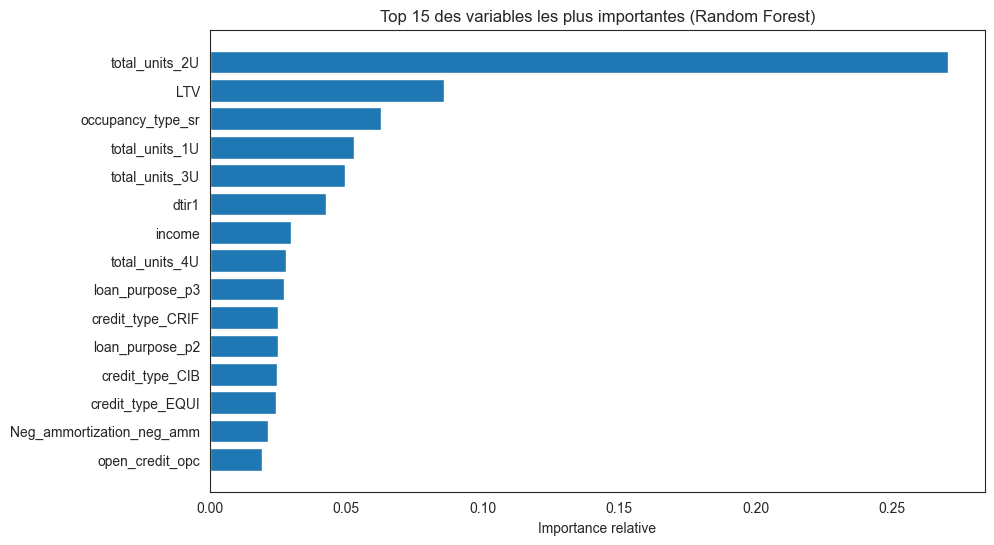

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Récupérer les noms des colonnes après le preprocessing
# (Grâce à ton set_config(transform_output="pandas"), c'est facile)
feature_names = X_train_preprocessed.columns

# 2. Récupérer les importances du modèle RF (ton champion)
importances = final_rf.feature_importances_

# 3. Créer un DataFrame pour faciliter le tri
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Afficher les 15 variables les plus importantes
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'].head(15), feature_importance_df['Importance'].head(15))
plt.gca().invert_yaxis()
plt.title("Top 15 des variables les plus importantes (Random Forest)")
plt.xlabel("Importance relative")
plt.show()

### 9. Analyse de l'Importance des Variables

Le graphique de Feature Importance de notre modèle **Random Forest** met en évidence les facteurs critiques influençant le score de crédit :

1.  **Structure de la propriété (`total_units`) :** Les propriétés à unités multiples semblent être le premier indicateur de segmentation du risque.

2.  **Ratios Financiers (`LTV`, `dtir1`) :** Le levier financier et le taux d'endettement sont, sans surprise, les piliers de la décision algorithmique.

3.  **Profil de Crédit (`credit_type`, `loan_purpose`) :** Le but du prêt et l'organisme de crédit source apportent une finesse supplémentaire à la prédiction.

**Conclusion :** Le modèle a appris des règles métier cohérentes avec les pratiques bancaires réelles, ce qui renforce notre confiance dans sa capacité à généraliser sur de nouveaux dossiers.

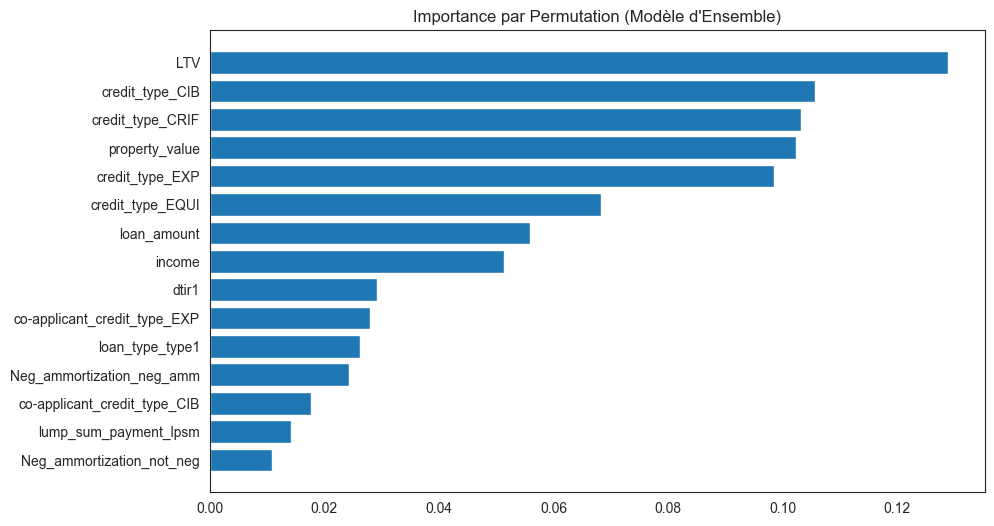

In [ ]:
from sklearn.inspection import permutation_importance


result = permutation_importance(
    voting_clf, X_test_pipe, y_test, n_repeats=5, random_state=42, n_jobs=-1
)

# Organiser les résultats
perm_importances_df = pd.DataFrame({
    'Feature': X_test_pipe.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(perm_importances_df['Feature'].head(15), perm_importances_df['Importance'].head(15))
plt.gca().invert_yaxis()
plt.title("Importance par Permutation (Modèle d'Ensemble)")
plt.show()

#### La méthode "Permutation Importance" (La plus précise) :

Le principe : On prend une colonne (ex: income), on mélange ses valeurs au hasard, et on regarde de combien le score du modèle chute. Si le score s'écroule, c'est que la variable était capitale.

## Time required !

In [ ]:
end_time = time.time()
total_duration = end_time - start_time

print(f"--- Processus terminé en {int(total_duration // 60)} min {total_duration % 60:.2f} s ---")

--- Processus terminé en 38 min 2.15 s ---
